In [1]:
# Import required libraries
from scipy import special as sp
import numpy as np
import matplotlib.pyplot as plt
from ipynb.fs.full.mie_functions import *
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

/Users/niya/Documents/polish_project/mie_functions.ipynb:833: SyntaxWarning: invalid escape sequence '\g'
  "        plt.show()\n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:834: SyntaxWarning: invalid escape sequence '\g'
  "        if savefig:\n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:835: SyntaxWarning: invalid escape sequence '\g'
  "            plt.savefig('field_components_plot.jpg', format='jpg', bbox_inches='tight')\n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:836: SyntaxWarning: invalid escape sequence '\g'
  "\n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:839: SyntaxWarning: invalid escape sequence '\g'
  "        E_x_values = E_x_values * E_0        \n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:980: SyntaxWarning: invalid escape sequence '\O'
  "\n",
/Users/niya/Documents/polish_project/mie_functions.ipynb:1170: SyntaxWarning: invalid escape sequence '\s'
  "            colors[:,ind] = np.gradie

In [2]:
# Import wavelength and refractive index values
ref_lam_gold, ref_n_gold, ref_k_gold = import_data("McPeak_gold.csv")
m_gold = ref_n_gold + 1j * ref_k_gold 

In [3]:
# Define radii and respective coordinate arrays for plotting
r1 = 0.01 #micrometers
r2 = 0.02 #micrometers
r3 = 0.03 #micrometers
r4 = 0.045 #micrometers
r5 = 0.06 #micrometers

x_arr1 = np.linspace(1.0, 2.0, 1000) * r1 * 1e3  #nm
x_arr2 = np.linspace(1.0, 2.0, 1000) * r2 * 1e3  #nm
x_arr3 = np.linspace(1.0, 2.0, 1000) * r3 * 1e3  #nm
x_arr4 = np.linspace(1.0, 2.0, 1000) * r4 * 1e3  #nm
x_arr5 = np.linspace(1.0, 2.0, 1000) * r5 * 1e3  #nm

y_arr = np.array([0.0]) #nm

r_arr1 = np.sqrt(x_arr1**2 + np.ones_like(x_arr1)*y_arr[0]**2) #nm
r_arr2 = np.sqrt(x_arr2**2 + np.ones_like(x_arr2)*y_arr[0]**2) #nm
r_arr3 = np.sqrt(x_arr3**2 + np.ones_like(x_arr3)*y_arr[0]**2) #nm
r_arr4 = np.sqrt(x_arr4**2 + np.ones_like(x_arr4)*y_arr[0]**2) #nm
r_arr5 = np.sqrt(x_arr5**2 + np.ones_like(x_arr5)*y_arr[0]**2) #nm

### Finding the resonant wavelength of nanoparticles of three different diameters

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3512178536.py:18: SyntaxWarning: invalid escape sequence '\s'
  subplots = [1,3], xlabel = 'Wavelength [nm]', ylabel = '$\sigma_{sc}$',


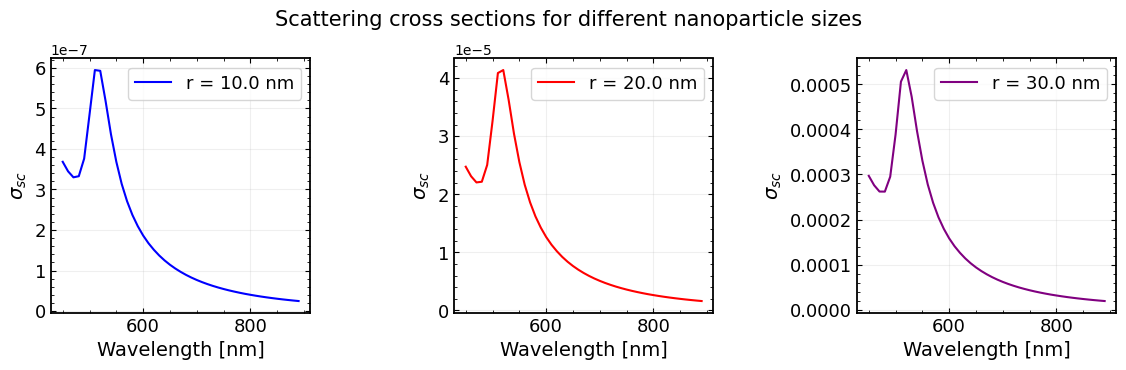

Resonant wavelength for r = 10.0 nm: 510.0 nm
Resonant wavelength for r = 20.0 nm: 520.0 nm
Resonant wavelength for r = 30.0 nm: 520.0 nm
Resonant wavelength for r = 45.0 nm: 520.0 nm
Resonant wavelength for r = 60.0 nm: 520.0 nm


In [4]:
# Calculate A1 and B1 Mie coeffs for given radii
A_r1, B_r1 = a_1_b_1_lists(ref_ind = m_gold, lam_list = ref_lam_gold, r = r1, YSK = True)
A_r2, B_r2 = a_1_b_1_lists(ref_ind = m_gold, lam_list = ref_lam_gold, r = r2, YSK = True)
A_r3, B_r3 = a_1_b_1_lists(ref_ind = m_gold, lam_list = ref_lam_gold, r = r3, YSK = True)
A_r4, B_r4 = a_1_b_1_lists(ref_ind = m_gold, lam_list = ref_lam_gold, r = r4, YSK = True)
A_r5, B_r5 = a_1_b_1_lists(ref_ind = m_gold, lam_list = ref_lam_gold, r = r4, YSK = True)
# Calculate scattering cross-section using Mie coeffs from lines above
sca_cross_section_r1 = sca_cross_section_analytical(A_r1, B_r1, ref_lam_gold) 
sca_cross_section_r2 = sca_cross_section_analytical(A_r2, B_r2, ref_lam_gold) 
sca_cross_section_r3 = sca_cross_section_analytical(A_r3, B_r3, ref_lam_gold) 
sca_cross_section_r4 = sca_cross_section_analytical(A_r4, B_r4, ref_lam_gold) 
sca_cross_section_r5 = sca_cross_section_analytical(A_r5, B_r5, ref_lam_gold) 
# Plot scattering cross-sections (restrict plotted vals so that maximum is easy to extract)
general_plot_style([ref_lam_gold[15:60]*1e3, ref_lam_gold[15:60]*1e3, ref_lam_gold[15:60]*1e3], 
                   [sca_cross_section_r1[15:60], sca_cross_section_r2[15:60], sca_cross_section_r3[15:60]], 
                   legendlabels = [f'r = {r1*1e3} nm', f'r = {r2*1e3} nm', f'r = {r3*1e3} nm'], 
                   colors = ['blue', 'red', 'purple'], ls = ['solid', 'solid', 'solid'], figsize = [12,4],
                   subplots = [1,3], xlabel = 'Wavelength [nm]', ylabel = '$\sigma_{sc}$', 
                   title = 'Scattering cross sections for different nanoparticle sizes', 
                   filename = 'scat_cross_sections.jpg', savefig = True)
# Find wavelength resulting in maximum scattering cross-section
lam1 = ref_lam_gold[np.where(sca_cross_section_r1 == np.max(sca_cross_section_r1[15:60]))][0]
lam2 = ref_lam_gold[np.where(sca_cross_section_r2 == np.max(sca_cross_section_r2[15:60]))][0]
lam3 = ref_lam_gold[np.where(sca_cross_section_r3 == np.max(sca_cross_section_r3[15:60]))][0]
lam4 = ref_lam_gold[np.where(sca_cross_section_r4 == np.max(sca_cross_section_r4[15:60]))][0]
lam5 = ref_lam_gold[np.where(sca_cross_section_r5 == np.max(sca_cross_section_r5[15:60]))][0]
# Print wavelength resulting in maximum scattering cross-section
print(f'Resonant wavelength for r = {r1*1e3} nm: {lam1*1e3} nm')
print(f'Resonant wavelength for r = {r2*1e3} nm: {lam2*1e3} nm')
print(f'Resonant wavelength for r = {r3*1e3} nm: {lam3*1e3} nm')
print(f'Resonant wavelength for r = {r4*1e3} nm: {lam4*1e3} nm')
print(f'Resonant wavelength for r = {r5*1e3} nm: {lam5*1e3} nm')

### Maximum field enhancement for nanoparticles of three different diameters

(incident field at resonant wavelength)

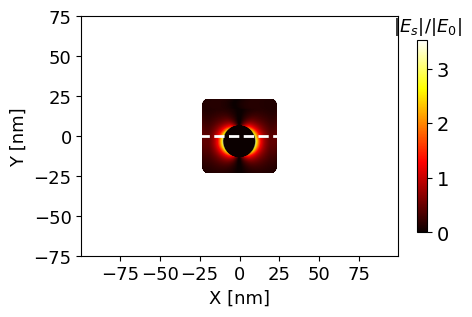

('At incoming wavelength of 510.0 nm',
 'Maximum scattered field = 3.529154514421217 E_0')

In [5]:
# r = 10 nm, resonant wavelength = 510 nm (TAKES LONG TO RUN, 1080 resolution required to get background in inset,
#                                          can be turned off with inset = False)
x_vals = np.linspace(-2*r1*1e3,2*r1*1e3,1080) #nm
y_vals = np.linspace(-2*r1*1e3,2*r1*1e3,1080) #nm

plot_scattered_field(x_vals, y_vals, 1e-15, m_gold, lam_list = ref_lam_gold, lam_value = lam1, r = r1, 
                     filename = 'enhancement_r_10.txt', n = 1, figsize = [5.1,5], savefig = True, dist = 0.2e-9)

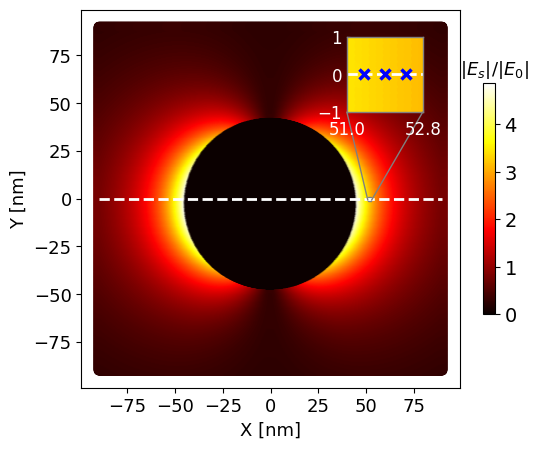

('At incoming wavelength of 520.0 nm',
 'Maximum scattered field = 4.867195325369463 E_0')

In [6]:
# r = 45 nm, resonant wavelength = 520 nm (TAKES LONG TO RUN, 1080 resolution required to get background in inset,
#                                          can be turned off with inset = False)
x_vals = np.linspace(-2*r4*1e3,2*r4*1e3,1080) #nm
y_vals = np.linspace(-2*r4*1e3,2*r4*1e3,1080) #nm

plot_scattered_field(x_vals, y_vals, 1e-15, m_gold, lam_list = ref_lam_gold, lam_value = lam4, r = r4, 
                     filename = 'enhancement_r_45.txt', n = 1, figsize = [6.1,6], inset = True,
                     savefig = True, dist = 0.9e-9)

### Rabi frequency and decay rates of the TLS 
(as a function of distance from the surface of the nanosphere)

<>:72: SyntaxWarning: invalid escape sequence '\,'
<>:96: SyntaxWarning: invalid escape sequence '\O'
<>:72: SyntaxWarning: invalid escape sequence '\,'
<>:96: SyntaxWarning: invalid escape sequence '\O'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/4115609208.py:72: SyntaxWarning: invalid escape sequence '\,'
  st2 = '$E_0^{No \,\, PDM}$' #used for plot labels
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/4115609208.py:96: SyntaxWarning: invalid escape sequence '\O'
  ax[v,w].set_ylabel('$\Omega_r$ [Hz]', fontsize=14)


Max Rabi freq at 11.011 nm for E_0 = 0.045, radius r = 10 nm
Max Rabi freq at 21.822 nm for E_0 = 0.04, radius r = 20 nm
Max Rabi freq at 33.874 nm for E_0 = 0.04, radius r = 30 nm
Max Rabi freq at 51.892 nm for E_0 = 0.0004, radius r = 45 nm


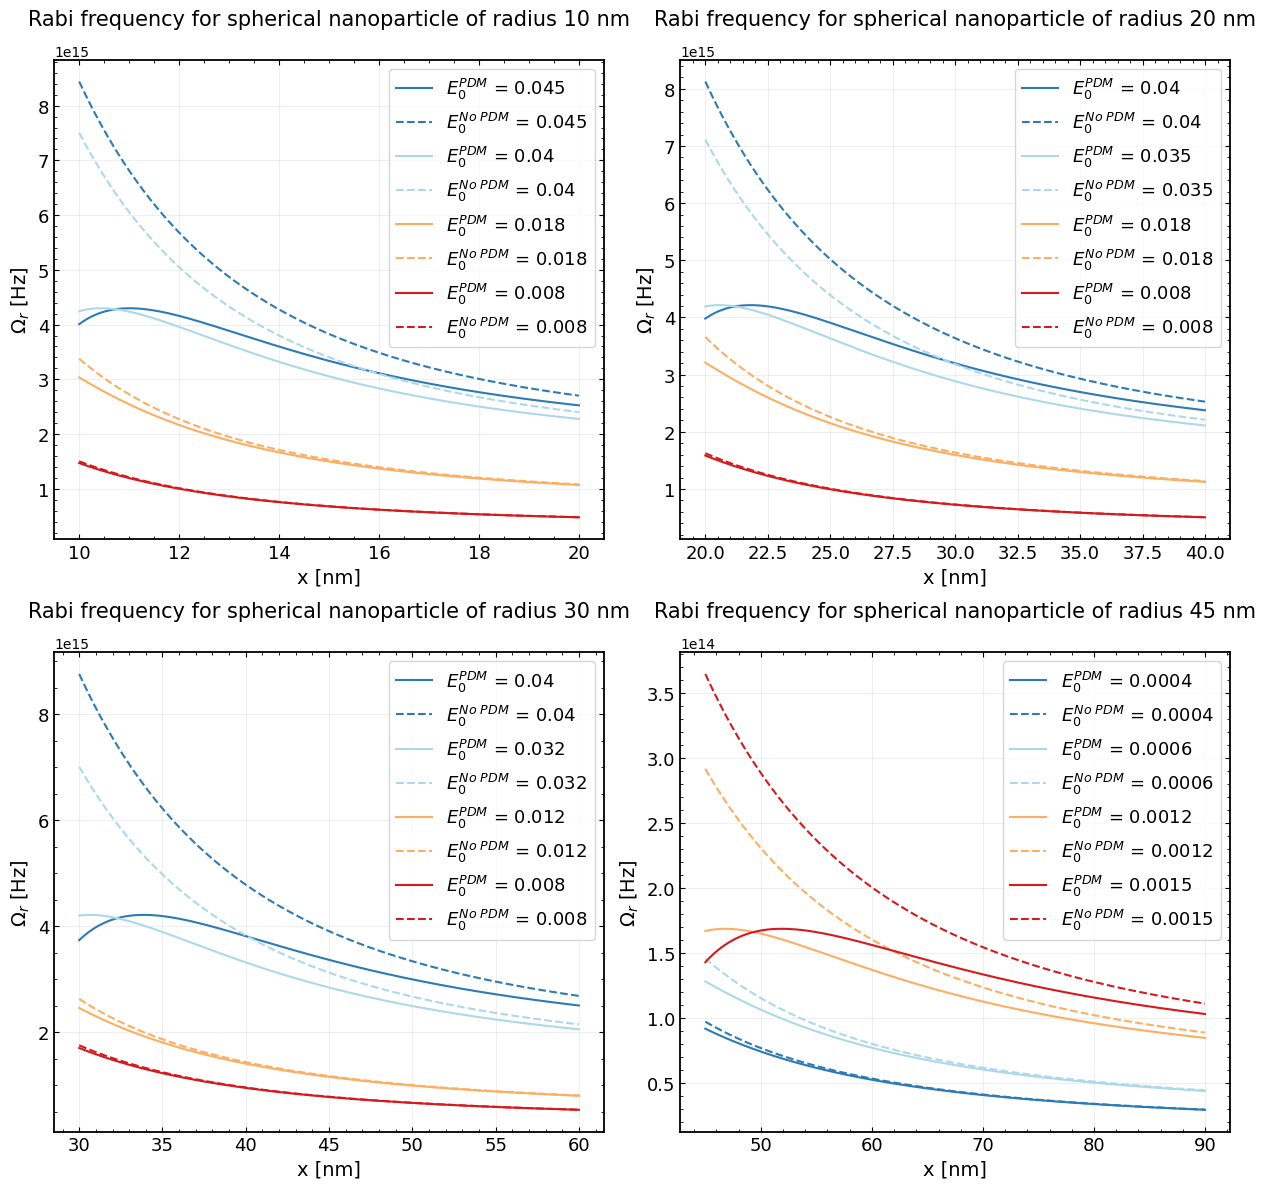

In [7]:
# Calculate Rabi frequency for all 5 nanoparticle radii [r1...r5] for different E0 values and fixed dperm = 1. 
# J_factors are the Bessel function corrections, omega_np are the Rabi frequencies without that 
# correction and omega are the full Rabi freq values. E is the field value in SI units.

E0s1 = [0.045, 0.040, 0.018, 0.008]
J_factor01, E01, omega_np01, omega01 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r1, 
                                                      n = 1, lam_value = lam1, E_0 = E0s1[0], print_vals = False)
J_factor11, E11, omega_np11, omega11 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r1, 
                                                      n = 1, lam_value = lam1, E_0 = E0s1[1], print_vals = False)
J_factor21, E21, omega_np21, omega21 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r1, 
                                                      n = 1, lam_value = lam1, E_0 = E0s1[2], print_vals = False)
J_factor31, E31, omega_np31, omega31 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r1, 
                                                      n = 1, lam_value = lam1, E_0 = E0s1[3], print_vals = False)
omega1 = [omega01, omega11, omega21, omega31] # store values including Bessel correction for plotting
omeganp1 = [omega_np01, omega_np11, omega_np21, omega_np31] # store values without Bessel correction for plotting
                                                            # (correction is J_1^2(kappa) with kappa = 0 when dperm 0)
E0s2 = [0.04, 0.035, 0.018, 0.008]
J_factor02, E02, omega_np02, omega02 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r2, 
                                                      n = 1, lam_value = lam2, E_0 = E0s2[0], print_vals = False)
J_factor12, E12, omega_np12, omega12 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r2,
                                                      n = 1, lam_value = lam2, E_0 = E0s2[1], print_vals = False)
J_factor22, E22, omega_np22, omega22 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r2, 
                                                      n = 1, lam_value = lam2, E_0 = E0s2[2], print_vals = False)
J_factor32, E32, omega_np32, omega32 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r2, 
                                                      n = 1, lam_value = lam2, E_0 = E0s2[3], print_vals = False)
omega2 = [omega02, omega12, omega22, omega32] # store values including Bessel correction for plotting
omeganp2 = [omega_np02, omega_np12, omega_np22, omega_np32] # store values without Bessel correction for plotting
 
E0s3 = [0.04, 0.032, 0.012, 0.008]
J_factor03, E03, omega_np03, omega03 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r3, 
                                                      n = 1, lam_value = lam3, E_0 = E0s3[0], print_vals = False)
J_factor13, E13, omega_np13, omega13 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r3, 
                                                      n = 1, lam_value = lam3, E_0 = E0s3[1], print_vals = False)
J_factor23, E23, omega_np23, omega23 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r3, 
                                                      n = 1, lam_value = lam3, E_0 = E0s3[2], print_vals = False)
J_factor33, E33, omega_np33, omega33 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r3,
                                                      n = 1, lam_value = lam3, E_0 = E0s3[3], print_vals = False)
omega3 = [omega03, omega13, omega23, omega33] # store values including Bessel correction for plotting
omeganp3 = [omega_np03, omega_np13, omega_np23, omega_np33] # store values without Bessel correction for plotting

# E0s4 = [0.035, 0.03, 0.015, 0.008]
E0s4 = [0.0015, 0.0012, 0.0006, 0.0004]
J_factor04, E04, omega_np04, omega04 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r4, 
                                                      n = 1, lam_value = lam4, E_0 = E0s4[0], print_vals = False,dperm=25.0, d_tr=1.0) # dperm=1.0, d_tr=1.0
J_factor14, E14, omega_np14, omega14 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r4, 
                                                      n = 1, lam_value = lam4, E_0 = E0s4[1], print_vals = False, dperm=25.0, d_tr=1.0)
J_factor24, E24, omega_np24, omega24 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r4, 
                                                      n = 1, lam_value = lam4, E_0 = E0s4[2], print_vals = False, dperm=25.0, d_tr=1.0)
J_factor34, E34, omega_np34, omega34 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, 
                                                      refr_ind = m_gold, lam_list = ref_lam_gold, r = r4, 
                                                      n = 1, lam_value = lam4, E_0 = E0s4[3], print_vals = False, dperm=25.0, d_tr=1.0)
omega4 = [omega04, omega14, omega24, omega34] # store values including Bessel correction for plotting
omeganp4 = [omega_np04, omega_np14, omega_np24, omega_np34] # store values without Bessel correction for plotting

#Plotting
st1 = '$E_0^{PDM}$' #used for plot labels
st2 = '$E_0^{No \,\, PDM}$' #used for plot labels
col = ['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6']
col1 = ['#d7191c', '#fdae61', '#2c7bb6', '#313695']
fig, ax = plt.subplots(2,2, figsize = (12.5, 12), layout = 'tight')

# reverse order of sequences:
E0s4 = E0s4[::-1]
omega4 = omega4[::-1]
omeganp4 = omeganp4[::-1]
col = col[::-1]
#On each subplot, plot Rabi freqeuncies with and without PDM for all E_0 values
for q in range(4):
    ax[0,0].plot(r_arr1, omega1[q], label = f'{st1} = {E0s1[q]}', color = col[q], ls = 'solid')
    ax[0,0].plot(r_arr1, omeganp1[q], label = f'{st2} = {E0s1[q]}', color = col[q], ls = '--')
    ax[0,1].plot(r_arr2, omega2[q], label = f'{st1} = {E0s2[q]}', color = col[q], ls = 'solid')
    ax[0,1].plot(r_arr2, omeganp2[q], label = f'{st2} = {E0s2[q]}', color = col[q], ls = '--')
    ax[1,0].plot(r_arr3, omega3[q], label = f'{st1} = {E0s3[q]}', color = col[q], ls = 'solid')
    ax[1,0].plot(r_arr3, omeganp3[q], label = f'{st2} = {E0s3[q]}', color = col[q], ls = '--')
    ax[1,1].plot(r_arr4, omega4[q], label = f'{st1} = {E0s4[q]}', color = col[q], ls = 'solid')
    ax[1,1].plot(r_arr4, omeganp4[q], label = f'{st2} = {E0s4[q]}', color = col[q], ls = '--')  
#Plotting style    
for v in range(2):
    for w in range(2):
        ax[v,w].set_xlabel('x [nm]', fontsize=14)
        ax[v,w].set_ylabel('$\Omega_r$ [Hz]', fontsize=14)
        ax[v,w].minorticks_on()
        ax[v,w].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=13)
        for axis in ['top','bottom','left','right']:
            ax[v,w].spines[axis].set_linewidth(1.3)
        ax[v,w].grid(alpha = 0.2)
        ax[v,w].legend(fontsize=13)
ax[0,0].set_title(f'Rabi frequency for spherical nanoparticle of radius {r1*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
ax[0,1].set_title(f'Rabi frequency for spherical nanoparticle of radius {r2*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
ax[1,0].set_title(f'Rabi frequency for spherical nanoparticle of radius {r3*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
ax[1,1].set_title(f'Rabi frequency for spherical nanoparticle of radius {r4*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
#Calculate position of Rabi freq maximum
d_1 = r_arr1[np.where(omega01 == np.max(omega01))]
d_2 = r_arr2[np.where(omega02 == np.max(omega02))]
d_3 = r_arr3[np.where(omega03 == np.max(omega03))]
d_4 = r_arr4[np.where(omega04 == np.max(omega04))]
#Print position of Rabi freq maximum
print(f'Max Rabi freq at {d_1[0]:.3f} nm for E_0 = {E0s1[0]}, radius r = {r1*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_2[0]:.3f} nm for E_0 = {E0s2[0]}, radius r = {r2*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_3[0]:.3f} nm for E_0 = {E0s3[0]}, radius r = {r3*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_4[0]:.3f} nm for E_0 = {E0s4[0]}, radius r = {r4*1e3:.0f} nm' )

<>:110: SyntaxWarning: invalid escape sequence '\O'
<>:110: SyntaxWarning: invalid escape sequence '\O'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3852452952.py:110: SyntaxWarning: invalid escape sequence '\O'
  ax[v,w].set_ylabel('$\Omega_r$ [Hz]', fontsize=14)


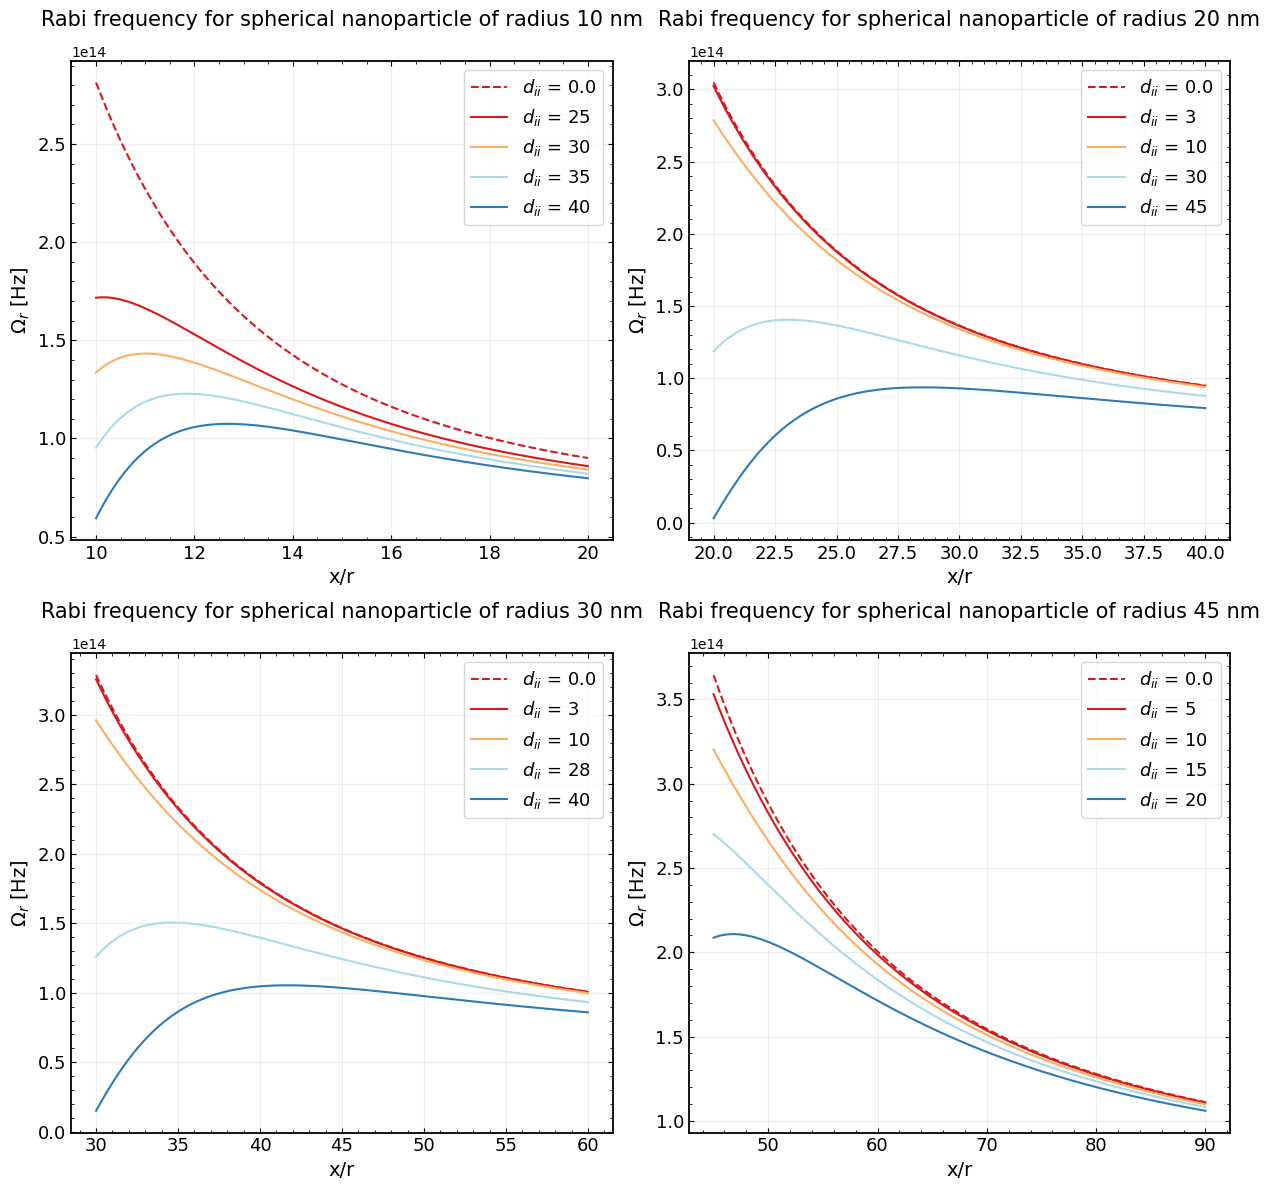

Max Rabi freq at 11.852 nm for E_0 = 0.0015, d_ii = 35, radius r = 10 nm
Max Rabi freq at 12.683 nm for E_0 = 0.0015, d_ii = 40, radius r = 10 nm
Max Rabi freq at 23.043 nm for E_0 = 0.0015, d_ii = 30, radius r = 20 nm
Max Rabi freq at 28.509 nm for E_0 = 0.0015, d_ii = 45, radius r = 20 nm
Max Rabi freq at 34.655 nm for E_0 = 0.0015, d_ii = 28, radius r = 30 nm
Max Rabi freq at 41.682 nm for E_0 = 0.0015, d_ii = 40, radius r = 30 nm
Max Rabi freq at 45.000 nm for E_0 = 0.0015, d_ii = 20, radius r = 45 nm
Max Rabi freq at 51.892 nm for E_0 = 0.0015, d_ii = 25, radius r = 45 nm
Max Rabi freq at 52.162 nm for E_0 = 0.0015, d_ii = 26, radius r = 60 nm
Max Rabi freq at 61.396 nm for E_0 = 0.0015, d_ii = 35, radius r = 60 nm


In [8]:
# Calculate Rabi frequency for all 5 nanoparticle radii [r1...r5] for different dperm values and fixed field 
# intensity. J_factors are the Bessel function corrections, omega_np are the Rabi frequencies without that 
# correction and omega are the full Rabi freq values. E is the field value in SI units.

E_0_fixed = 0.0015
d_ii_1 = [0.0, 5, 13, 35, 50] #Uncomment for time evolution and Rabi frequency plots (best values)
d_ii_1 = [0.0, 25, 30, 35, 40] #Uncomment for coherence time plots

# r = 10 nm
J_factor05, E05, omega_np05, omega05 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_1[1], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r1, n = 1, lam_value = lam1, E_0 = E_0_fixed)
J_factor15, E15, omega_np15, omega15 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_1[2], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r1, n = 1, lam_value = lam1, E_0 = E_0_fixed)
J_factor25, E25, omega_np25, omega25 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_1[3], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r1, n = 1, lam_value = lam1, E_0 = E_0_fixed)
J_factor35, E35, omega_np35, omega35 = rabi_frequency(x_points = x_arr1, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_1[4], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r1, n = 1, lam_value = lam1, E_0 = E_0_fixed)
omega5 = [omega_np05, omega05, omega15, omega25, omega35] # store Rabi freq values for plotting

# r = 20 nm
d_ii_2 = [0.0, 3, 10, 30, 45]
J_factor06, E06, omega_np06, omega06 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_2[1], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r2, n = 1, lam_value = lam2, E_0 = E_0_fixed)
J_factor16, E16, omega_np16, omega16 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_2[2], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r2, n = 1, lam_value = lam2, E_0 = E_0_fixed)
J_factor26, E26, omega_np26, omega26 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_2[3], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r2, n = 1, lam_value = lam2, E_0 = E_0_fixed)
J_factor36, E36, omega_np36, omega36 = rabi_frequency(x_points = x_arr2, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_2[4], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r2, n = 1, lam_value = lam2, E_0 = E_0_fixed)
omega6 = [omega_np06, omega06, omega16, omega26, omega36] # store Rabi freq values for plotting

# r = 30 nm
d_ii_3 = [0.0, 3, 10, 28, 40]
J_factor07, E07, omega_np07, omega07 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_3[1], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r3, n = 1, lam_value = lam3, E_0 = E_0_fixed)
J_factor17, E17, omega_np17, omega17 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_3[2], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r3, n = 1, lam_value = lam3, E_0 = E_0_fixed)
J_factor27, E27, omega_np27, omega27 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_3[3], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r3, n = 1, lam_value = lam3, E_0 = E_0_fixed)
J_factor37, E37, omega_np37, omega37 = rabi_frequency(x_points = x_arr3, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_3[4], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r3, n = 1, lam_value = lam3, E_0 = E_0_fixed)
omega7 = [omega_np07, omega07, omega17, omega27, omega37] # store Rabi freq values for plotting

# r = 45 nm
d_ii_4 = [0.0, 5, 10, 15, 20, 25] #Uncomment for time evolution and Rabi frequency plots (best values)
# d_ii_4 = [0.0, 3, 10, 25, 38] #Uncomment for time evolution and Rabi frequency plots (best values)
# d_ii_4 = [0.0, 25, 30, 35, 40] #Uncomment for coherence time plots

J_factor08, E08, omega_np08, omega08 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_4[1], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r4, n = 1, lam_value = lam4, E_0 = E_0_fixed)
J_factor18, E18, omega_np18, omega18 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_4[2], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r4, n = 1, lam_value = lam4, E_0 = E_0_fixed)
J_factor28, E28, omega_np28, omega28 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_4[3], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r4, n = 1, lam_value = lam4, E_0 = E_0_fixed)
J_factor38, E38, omega_np38, omega38 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_4[4], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r4, n = 1, lam_value = lam4, E_0 = E_0_fixed,)
J_factor48, E48, omega_np48, omega48 = rabi_frequency(x_points = x_arr4, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_4[5], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r4, n = 1, lam_value = lam4, E_0 = E_0_fixed,)
omega8 = [omega_np08, omega08, omega18, omega28, omega38, omega48] # store Rabi freq values for plotting

# r = 60 nm
d_ii_5 = [0.0, 3, 10, 26, 35]
J_factor09, E09, omega_np09, omega09 = rabi_frequency(x_points = x_arr5, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_5[1], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r5, n = 1, lam_value = lam5, E_0 = E_0_fixed)
J_factor19, E19, omega_np19, omega19 = rabi_frequency(x_points = x_arr5, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_5[2], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r5, n = 1, lam_value = lam5, E_0 = E_0_fixed)
J_factor29, E29, omega_np29, omega29 = rabi_frequency(x_points = x_arr5, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_5[3], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r5, n = 1, lam_value = lam5, E_0 = E_0_fixed)
J_factor39, E39, omega_np39, omega39 = rabi_frequency(x_points = x_arr5, y = y_arr[0], z = 1e-15, dperm = \
                                                      d_ii_5[4], refr_ind = m_gold, lam_list = ref_lam_gold, 
                                                      r = r5, n = 1, lam_value = lam5, E_0 = E_0_fixed,)
omega9 = [omega_np09, omega09, omega19, omega29, omega39] # store Rabi freq values for plotting

#Plotting
st = '$d_{ii}$' #used for plot labels
fig, ax = plt.subplots(2,2, figsize = (12.5, 12), layout = 'tight')
lss = ['--', 'solid', 'solid', 'solid', 'solid', 'solid']
col2 = ['#d7191c', '#d7191c', '#fdae61', '#abd9e9', '#2c7bb6']

#On each of the four subplots, plot the rabi frequency values for radii r1 to r4 
for q in range(5):
    ax[0,0].plot(r_arr1, omega5[q], label = f'{st} = {d_ii_1[q]}', color = col2[q], ls = lss[q])
    ax[0,1].plot(r_arr2, omega6[q], label = f'{st} = {d_ii_2[q]}', color = col2[q], ls = lss[q])
    ax[1,0].plot(r_arr3, omega7[q], label = f'{st} = {d_ii_3[q]}', color = col2[q], ls = lss[q])
    ax[1,1].plot(r_arr4, omega8[q], label = f'{st} = {d_ii_4[q]}', color = col2[q], ls = lss[q])
#Plotting style    
for v in range(2):
    for w in range(2):
        ax[v,w].set_xlabel('x/r', fontsize=14)
        ax[v,w].set_ylabel('$\Omega_r$ [Hz]', fontsize=14)
        ax[v,w].minorticks_on()
        ax[v,w].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=13)
        for axis in ['top','bottom','left','right']:
            ax[v,w].spines[axis].set_linewidth(1.3)
        ax[v,w].grid(alpha = 0.2)
        ax[v,w].legend(fontsize=13)
ax[0,0].set_title(f'Rabi frequency for spherical nanoparticle of radius {r1*1e3:.0f} nm', fontsize=15, \
                  wrap = True, pad = 25)
ax[0,1].set_title(f'Rabi frequency for spherical nanoparticle of radius {r2*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
ax[1,0].set_title(f'Rabi frequency for spherical nanoparticle of radius {r3*1e3:.0f} nm', fontsize=15, \
                  wrap = True, pad = 25)
ax[1,1].set_title(f'Rabi frequency for spherical nanoparticle of radius {r4*1e3:.0f} nm', fontsize=15, \
                  wrap = False, pad = 25)
#Find x-distance (at y=0.0) where the Rabi frequency is at its peak value
d_5 = x_arr1[np.where(omega25 == np.max(omega25))]
d_6 = x_arr1[np.where(omega35 == np.max(omega35))]
d_7 = x_arr2[np.where(omega26 == np.max(omega26))]
d_8 = x_arr2[np.where(omega36 == np.max(omega36))]
d_9 = x_arr3[np.where(omega27 == np.max(omega27))]
d_10 = x_arr3[np.where(omega37 == np.max(omega37))]
d_11 = x_arr4[np.where(omega28 == np.max(omega28))]
d_12 = x_arr4[np.where(omega48 == np.max(omega48))]
d_13 = x_arr4[np.where(omega29 == np.max(omega29))]
d_14 = x_arr4[np.where(omega39 == np.max(omega39))]

plt.show()
#Print out positions of maximum Rabi freq values (to be used in TLS evolution plots)
print(f'Max Rabi freq at {d_5[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_1[-2]}, radius r = {r1*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_6[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_1[-1]}, radius r = {r1*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_7[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_2[-2]}, radius r = {r2*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_8[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_2[-1]}, radius r = {r2*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_9[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_3[-2]}, radius r = {r3*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_10[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_3[-1]}, radius r = {r3*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_11[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_4[-2]}, radius r = {r4*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_12[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_4[-1]}, radius r = {r4*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_13[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_5[-2]}, radius r = {r5*1e3:.0f} nm' )
print(f'Max Rabi freq at {d_14[0]:.3f} nm for E_0 = {E_0_fixed}, d_ii = {d_ii_5[-1]}, radius r = {r5*1e3:.0f} nm' )

<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:109: SyntaxWarning: invalid escape sequence '\O'
<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:109: SyntaxWarning: invalid escape sequence '\O'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3255049061.py:86: SyntaxWarning: invalid escape sequence '\D'
  title=f'PDM $\Delta$d',
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3255049061.py:109: SyntaxWarning: invalid escape sequence '\O'
  ax[i].set_ylabel('$\Omega$ [THz]', fontsize=39)
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3255049061.py:124: RuntimeWarning: invalid value encountered in divide
  om_pdm = 2*g_x*sp.jv(1, kappa_z)/kappa_z


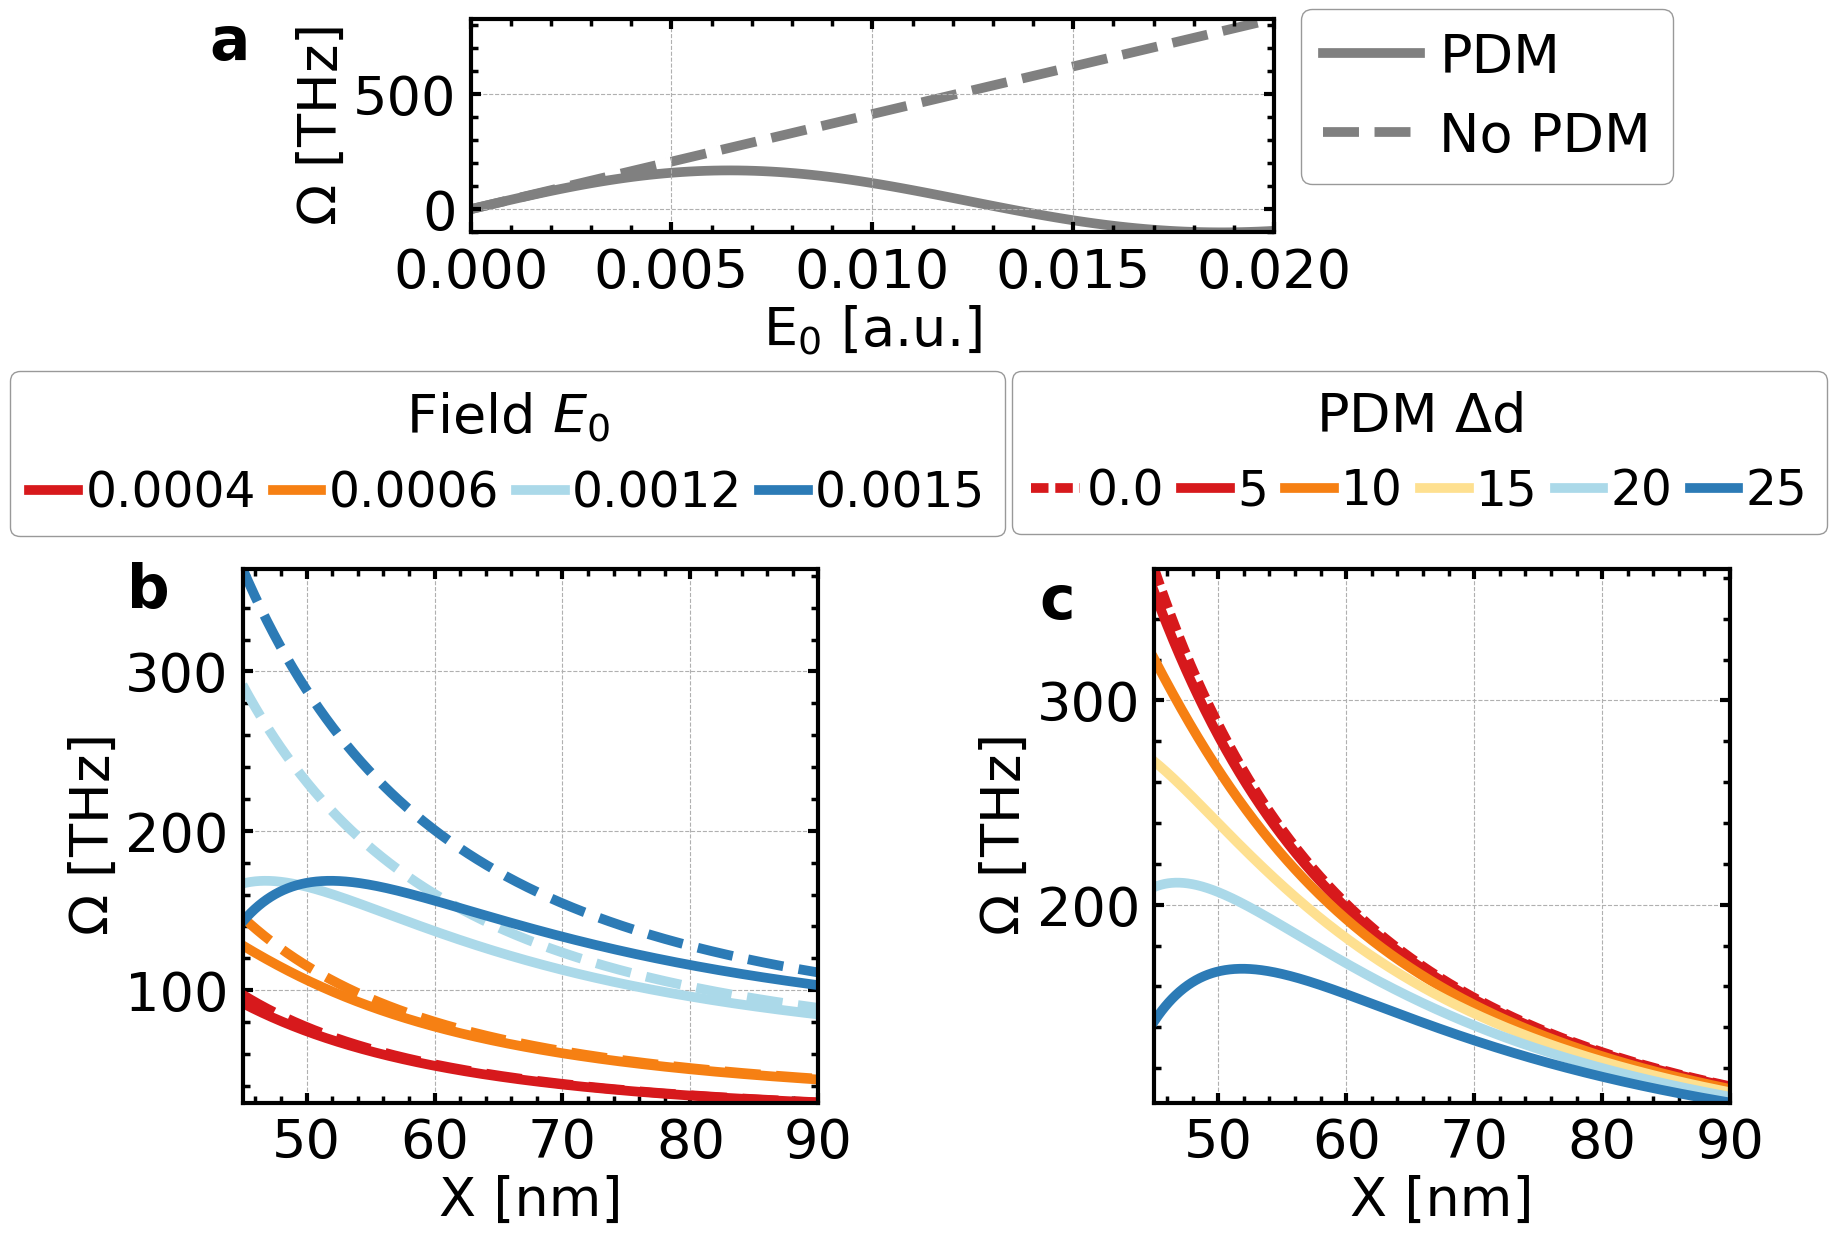

In [9]:
cm = 1 / 2.54  # cm to inches
col = ['#d7191c', '#f68013', '#abd9e9', '#2c7bb6']
st1 = '$E_0$' #used for plot labels

# fig, ax = plt.subplots(1, 2, figsize=(50.75 * cm, 21.75 * cm))

# Create figure
fig = plt.figure(figsize=(48.75 * cm, 35.75 * cm))

# Define a 2-row, 5-column grid
gs = gridspec.GridSpec(2, 5)

# Define a 2-row, 3-column grid
gs = gridspec.GridSpec(2, 7, width_ratios=[1, 1, 1, 1, 1, 1, 1], height_ratios=[0.4,1],hspace=0.9,wspace=0.9)

# Top subplot: centered in the middle column
ax1 = fig.add_subplot(gs[0, 1:5])  # Top, middle column

# Bottom subplots: equal width on the left and right columns
ax2 = fig.add_subplot(gs[1, 0:3])  # Bottom-left
ax3 = fig.add_subplot(gs[1, 4:7])  # Bottom-right

ax=[ax1,ax2,ax3]

# plot data
for q in range(4):
    ax[1].plot(r_arr4, omega4[q]*1e-12, label=f'{E0s4[q]}', color=col[q], ls='solid', linewidth=7.0)
    ax[1].plot(r_arr4, omeganp4[q]*1e-12, color=col[q], ls='--', linewidth=7.0)

# get data line handles and labels
data_handles, data_labels = ax[1].get_legend_handles_labels()

# combine handles: first symbolic lines, then data lines
combined_handles = data_handles
combined_labels = data_labels

# formatting legend
ncol = max(len(combined_labels) // 2, 4)  # at least 4 cols for better spacing
ax[1].legend(
    handles=combined_handles,
    labels=combined_labels,
    fontsize=35,
    loc='upper center',
    bbox_to_anchor=(0.46, 1.37),  # legend above plot
    ncol=ncol,
    borderaxespad=0,
    columnspacing=0.35,
    handlelength=1.0,
    handletextpad=0.15,
    frameon=True,
    edgecolor='gray',
    title=f'Field $E_0$', 
    title_fontsize=39)

offset_text_obj = ax[1].yaxis.get_offset_text()
offset_text_obj.set_fontsize(34)
ax[1].set_xlim(left=45, right=90)

st = '$d_{ii}$' #used for plot labels
lss = ['--','solid', 'solid', 'solid', 'solid', 'solid'] 
col = ['#d7191c','#d7191c','#f68013', '#fee090', '#abd9e9', '#2c7bb6']

# plot Rabi frequency as a function of distance from nanosphere for all values of dperm
ax[2].plot(r_arr4, omega8[0]*1e-12, label = f'{d_ii_4[0]}', color = col[0], ls = lss[0], linewidth = 7.0, dashes=(1.8, 0.7))
for q in range(1,6):
    ax[2].plot(r_arr4, omega8[q]*1e-12, label = f'{d_ii_4[q]}', color = col[q], ls = lss[q], linewidth = 7.0)

# get solid line handles and labels (data lines)
data_handles, data_labels = ax[2].get_legend_handles_labels()

# legend formatting
ncol = max(len(combined_labels) // 2, 6)  # Ensure at least 3 cols for better spacing
ax[2].legend(
    handles=data_handles,
    labels=data_labels,
    fontsize=35,
    loc='upper center',
    bbox_to_anchor=(0.46, 1.37),  # Center above plot
    ncol=ncol,
    borderaxespad=0,
    columnspacing=0.35,
    handlelength=1.0,
    handletextpad=0.15,
    frameon=True,
    edgecolor='gray',
    title=f'PDM $\Delta$d', 
    title_fontsize=39)

offset_text_obj = ax[2].yaxis.get_offset_text()
offset_text_obj.set_fontsize(34)

# formatting
for i in range(1,3):
    ax[i].set_xlabel('X [nm]', fontsize=39)
    ax[i].set_xticks([50, 60, 70, 80, 90])
    ax[i].set_xlim(45,90)
for i in range(3):
    ax[i].margins(x=0) # Remove whitespace padding
    ax[i].margins(y=0) # Remove whitespace padding
    ax[i].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=39)
    ax[i].minorticks_on()
    for axis in ['top', 'bottom', 'left', 'right']:
        ax[i].spines[axis].set_linewidth(3.0)
    ax[i].grid(alpha=1.0, ls='--')
    ax[i].tick_params(axis='x', width=3.0, length=7, direction='in', pad=10)
    ax[i].tick_params(axis='y', width=3.0, length=7, direction='in', pad=10)
    ax[i].tick_params(axis='x', which = 'minor', width=2.5, length=5, direction='in', pad=10)
    ax[i].tick_params(axis='y', which = 'minor', width=2.5, length=5, direction='in', pad=10)
    ax[i].set_ylabel('$\Omega$ [THz]', fontsize=39)
    
E0 = np.linspace(0.0,0.02,100)*5.14220675112*1e11
hbar = 1.054571817e-34 # reduced Planck constant[Js]
c = 299792458 # speed of light [m/s]
lam = lam4*1e-6
w_c = 2*np.pi*c/lam
w_eg = w_c
d_eg = 1.0*8.4783536198e-30
d_perm = 25.0*8.4783536198e-30

g_z = E0*d_perm/hbar
g_x = E0*d_eg/hbar
kappa_z = g_z/w_c
om_no_pdm = g_x
om_pdm = 2*g_x*sp.jv(1, kappa_z)/kappa_z
om_pdm[0] = 0.0
ax[0].plot(E0*1e-11/5.14220675112,om_pdm*1e-12,label='PDM',linewidth=7.0, color = 'gray', linestyle = 'solid', zorder=1)
ax[0].plot(E0*1e-11/5.14220675112,om_no_pdm*1e-12,label='No PDM',linewidth=7.0, color = 'gray', linestyle = '--', zorder=0)
ax[0].set_xlabel('E$_0$ [a.u.]', fontsize=39)
offset_text_obj = ax[0].yaxis.get_offset_text()
offset_text_obj.set_fontsize(32)
ax[0].legend(
    fontsize=39,
    loc='lower left',
    bbox_to_anchor=(1.0, 0.1), 
    ncol=1,                      
    frameon=True,
    edgecolor='gray',
    handlelength=1.8,
    handletextpad=0.35,)
ax[0].set_xticks([0.0,0.005,0.01,0.015,0.02])
# Add subplot labels
ax[0].text(-0.0065,650.0,'a', fontsize = 43, weight='bold')
ax[1].text(36,340.0,'b', fontsize = 43, weight='bold')
ax[2].text(36,340.0,'c', fontsize = 43, weight='bold')

plt.savefig(fname = f'field_dependence2.jpg', format = 'jpg', dpi=600, bbox_inches='tight')
plt.show()

### Coherence times

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\;'
<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\;'
<>:56: SyntaxWarning: invalid escape sequence '\D'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3532794881.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax[i].set_xlabel('$\Delta$X [nm]', fontsize=36)
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3532794881.py:40: SyntaxWarning: invalid escape sequence '\;'
  ax[1].set_ylabel('$t^{\;PDM}_c\;/\;t^{\;No\;PDM}_c$', fontsize=36)
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3532794881.py:56: SyntaxWarning: invalid escape sequence '\D'
  title=f'PDM $\Delta$d',
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3532794881.py:13: RuntimeWarning: divide by zero encountered in divide
  1e9*np.abs(1/(np.pi*(omega8[q]

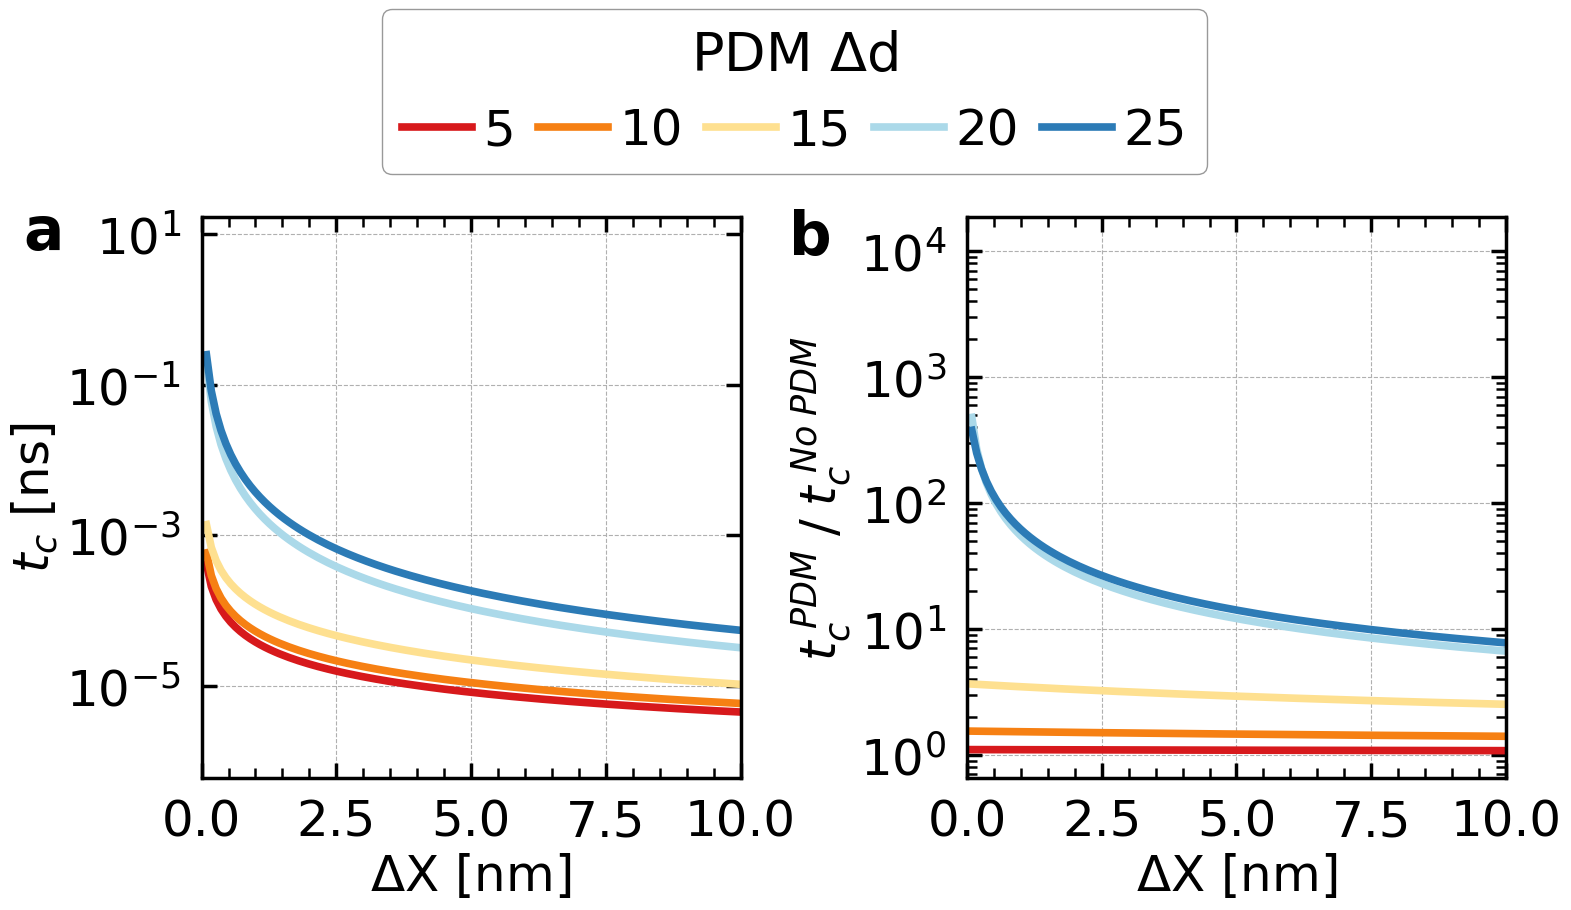

In [10]:
# coherence times for all values of the PDMs
cm = 1/2.54 #used for figure size
st = '$d_{ii}$' #used for plot labels
fig, ax = plt.subplots(1,2, figsize=(42.75 * cm, 18.51 * cm))
lss1 = ['--', '--', '--', '--', '--']
lss2 = ['solid', 'solid', 'solid', 'solid', 'solid', 'solid']
col = ['#d7191c','#d7191c','#f68013', '#fee090', '#abd9e9', '#2c7bb6']

plt.subplots_adjust(wspace=0.42)  # Increase to add more space

for q in range(1,6):  
    ax[0].plot(2*(r_arr4-r_arr4[np.where(omega8[q]==np.max(omega8[q]))]), 
            1e9*np.abs(1/(np.pi*(omega8[q]-np.max(omega8[q])))), 
            color = col[q], linewidth = 5.5, label = f'{d_ii_4[q]}')

for q in range(1,6): # r = 45 nm
    ax[1].plot(2*(r_arr4-r_arr4[np.where(omega8[q]==np.max(omega8[q]))]), 
            np.abs(1/((omega8[q]-omega8[q][np.where(omega8[q]==np.max(omega8[q]))])))/np.abs(1/((omega8[0]
            -omega8[0][np.where(omega8[q]==np.max(omega8[q]))]))), 
            color = col[q], linewidth = 5.5, label = f'{d_ii_4[q]}')

# formatting
for i in range(2):
    ax[i].set_xlabel('$\Delta$X [nm]', fontsize=36)
    ax[i].minorticks_on()
    ax[i].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=36)
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(2.5)
    ax[i].grid(alpha = 1.0, ls = '--')
    ax[i].set_xlim([0,10])
    ax[i].set_xticks([0, 2.5, 5, 7.5, 10])
    ax[i].tick_params(axis='x', width=2.5, length=11, direction='in', pad=14)
    ax[i].tick_params(axis='y', width=2.5, length=11, direction='in', pad=15)
    ax[i].tick_params(axis='x', which = 'minor', width=1.8, length=7, direction='in', pad=14)
    ax[i].tick_params(axis='y', which = 'minor', width=1.8, length=7, direction='in', pad=15)    
ax[1].set_yscale("log")
ax[0].set_yscale("log")

ax[0].set_ylabel('$t_c$ [ns]', fontsize=36)
ax[1].set_ylabel('$t^{\;PDM}_c\;/\;t^{\;No\;PDM}_c$', fontsize=36)

data_handles, data_labels = ax[0].get_legend_handles_labels()
ax[0].legend(
    handles=data_handles,
    labels=data_labels,
    fontsize=36,
    loc='upper center',
    bbox_to_anchor=(1.1, 1.37),  # Center above plot
    ncol=5,
    borderaxespad=0,
    columnspacing=0.47,
    handlelength=1.4,
    handletextpad=0.22,
    frameon=True,
    edgecolor='gray',
    title=f'PDM $\Delta$d', 
    title_fontsize=39)

# add labels
ax[0].text(-3.3,6.3,'a', fontsize = 43, weight='bold')
ax[1].text(-3.3,9.4e3,'b', fontsize = 43, weight='bold')

# save plot and show
plt.savefig(fname = f'coherence_times2.jpg', format = 'jpg', dpi=600, bbox_inches='tight')
plt.show()

### Decay rates

In [11]:
m_gold_val1 = m_gold[np.where(ref_lam_gold == lam1)] #for decay rate f-ns, a single ref ind must be passed rather 
m_gold_val2 = m_gold[np.where(ref_lam_gold == lam2)] #than list
m_gold_val3 = m_gold[np.where(ref_lam_gold == lam3)]
m_gold_val4 = m_gold[np.where(ref_lam_gold == lam4)]

x_arr11 = np.linspace(1.2, 3.0, 100) * r1 * 1e3  #nm     # make new arrays with less values so that 
x_arr22 = np.linspace(1.0, 1.35, 100) * r2 * 1e3  #nm      subsequent f-ns run faster
x_arr33 = np.linspace(1.0, 4.2, 100) * r3 * 1e3  #nm
x_arr44 = np.linspace(1.0, 3.1, 100) * r4 * 1e3  #nm

<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3409214476.py:23: SyntaxWarning: invalid escape sequence '\g'
  labels = ['$\gamma_{\perp}$', '$\gamma_{\, \|}$', '$\gamma^{\, R}_{\perp}$', '$\gamma^{\, R}_{\, \|}$']
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3409214476.py:23: SyntaxWarning: invalid escape sequence '\g'
  labels = ['$\gamma_{\perp}$', '$\gamma_{\, \|}$', '$\gamma^{\, R}_{\perp}$', '$\gamma^{\, R}_{\, \|}$']
/var/folders/6j/zgxsrqsx

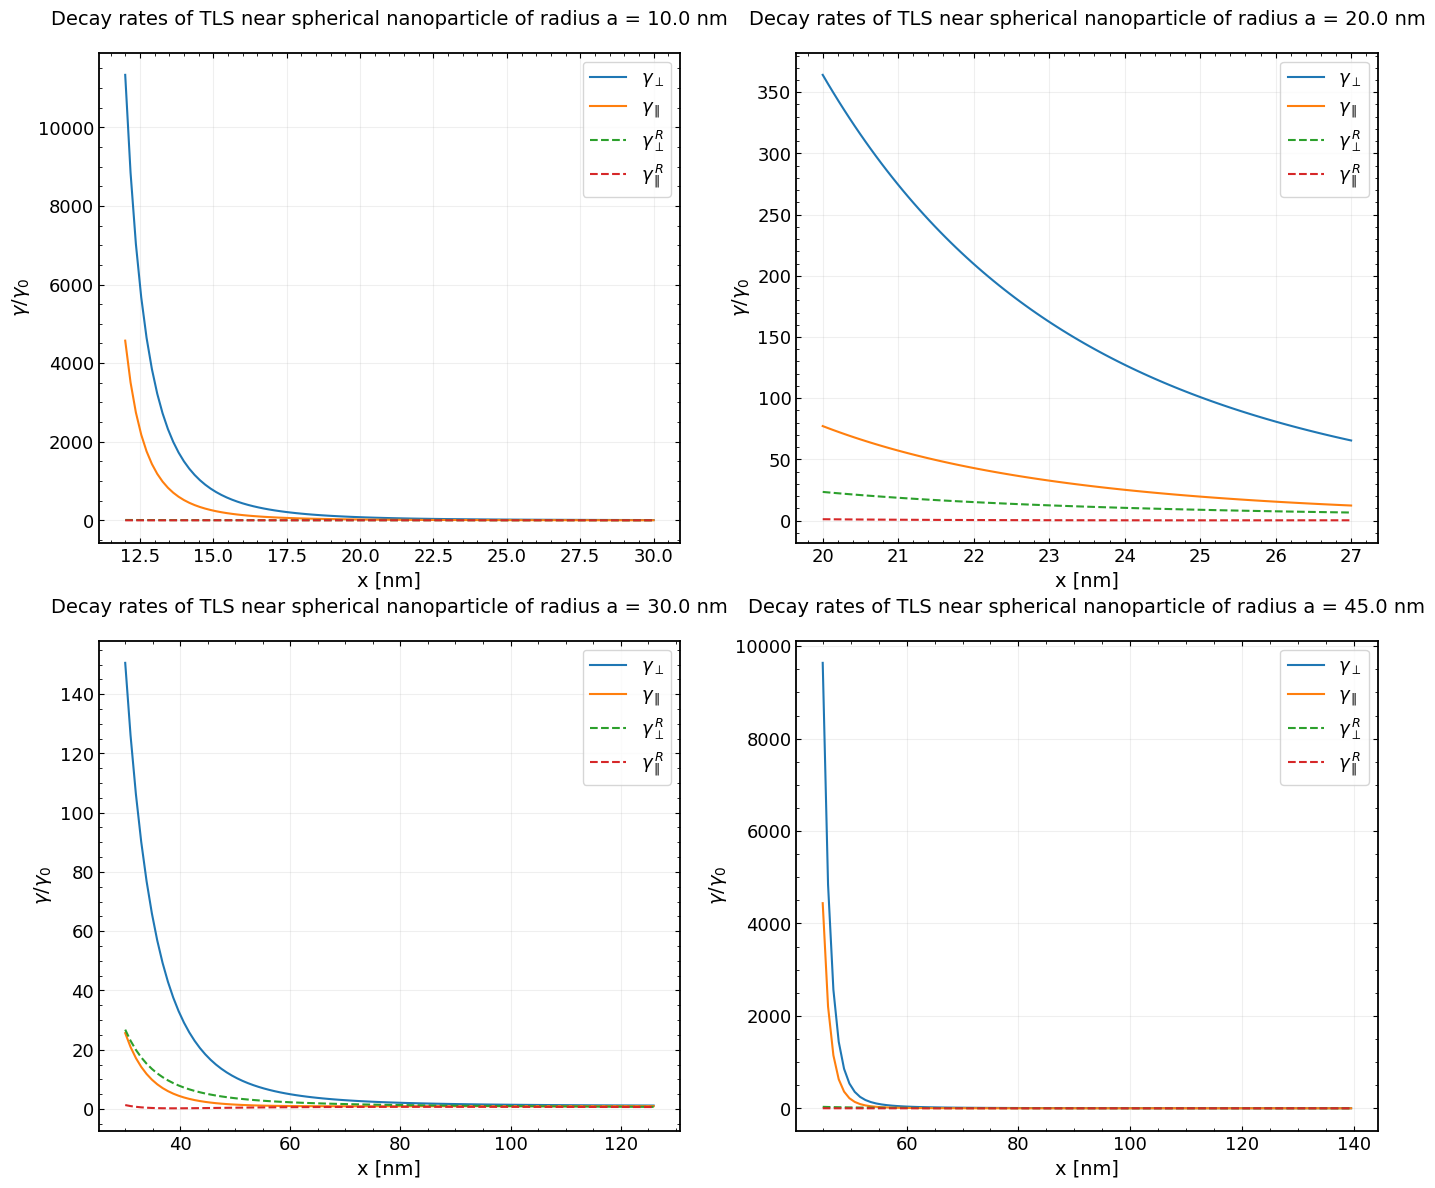

In [12]:
# Calculate decay rates for the different radii [r1...r4]. The rates relevant for the project are the gamma_norm_vals
A_list1, B_list1, gamma_norm_vals1, gamma_tang_vals1, gamma_norm_rad_vals1, gamma_tang_rad_vals1 = gamma_factors(
                                x_arr11*1e-9, m_gold_val1, lam_val = lam1*1e-6, r = r1*1e-6, n = 1, order = 20, 
                                plot = False, savefig = False, lim = False)
A_list2, B_list2, gamma_norm_vals2, gamma_tang_vals2, gamma_norm_rad_vals2, gamma_tang_rad_vals2 = gamma_factors(
                                x_arr22*1e-9, m_gold_val2, lam_val = lam2*1e-6, r = r2*1e-6, n = 1, order = 1, 
                                plot = False, savefig = False, lim = False)
A_list3, B_list3, gamma_norm_vals3, gamma_tang_vals3, gamma_norm_rad_vals3, gamma_tang_rad_vals3 = gamma_factors(
                                x_arr33*1e-9, m_gold_val3, lam_val = lam3*1e-6, r = r3*1e-6, n = 1, order = 1, 
                                plot = False, savefig = False, lim = False)
A_list4, B_list4, gamma_norm_vals4, gamma_tang_vals4, gamma_norm_rad_vals4, gamma_tang_rad_vals4 = gamma_factors(
                                x_arr44*1e-9, m_gold_val4, lam_val = lam4*1e-6, r = r4*1e-6, n = 1, order = 20, 
                                plot = False, savefig = False, lim = False)
# Store the enhancement of decay rates for plotting. Each array contains decay rates for all orientations of TLS 
# around nanosphere of given radius ri
plot_gammas1 = [gamma_norm_vals1, gamma_tang_vals1, gamma_norm_rad_vals1, gamma_tang_rad_vals1]
plot_gammas2 = [gamma_norm_vals2, gamma_tang_vals2, gamma_norm_rad_vals2, gamma_tang_rad_vals2]
plot_gammas3 = [gamma_norm_vals3, gamma_tang_vals3, gamma_norm_rad_vals3, gamma_tang_rad_vals3]
plot_gammas4 = [gamma_norm_vals4, gamma_tang_vals4, gamma_norm_rad_vals4, gamma_tang_rad_vals4]

# Plot decay rate enhancement
lss = ['solid', 'solid', '--', '--']
labels = ['$\gamma_{\perp}$', '$\gamma_{\, \|}$', '$\gamma^{\, R}_{\perp}$', '$\gamma^{\, R}_{\, \|}$']

fig, ax = plt.subplots(2,2, figsize = (16.5, 14))
for o in range(4):
    ax[0,0].plot(x_arr11, plot_gammas1[o], label = labels[o], ls = lss[o])
    ax[0,1].plot(x_arr22, plot_gammas2[o], label = labels[o], ls = lss[o])
    ax[1,0].plot(x_arr33, plot_gammas3[o], label = labels[o], ls = lss[o])  
    ax[1,1].plot(x_arr44, plot_gammas4[o], label = labels[o], ls = lss[o])
    
# Plotting style    
for v in range(2):
    for w in range(2):
        ax[v,w].set_xlabel('x [nm]', fontsize=14)
        ax[v,w].set_ylabel('$\gamma / \gamma_0$', fontsize=14)
        ax[v,w].minorticks_on()
        ax[v,w].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=13)
        for axis in ['top','bottom','left','right']:
            ax[v,w].spines[axis].set_linewidth(1.3)
        ax[v,w].grid(alpha = 0.2)
        ax[v,w].legend(fontsize=13)
        
ax[0,0].set_title(f'Decay rates of TLS near spherical nanoparticle of radius a = {r1*10**3} nm', fontsize=14, \
            loc = 'center', wrap = True, pad=20)
ax[0,1].set_title(f'Decay rates of TLS near spherical nanoparticle of radius a = {r2*10**3} nm', fontsize=14, \
            loc = 'center', wrap = True, pad=20)
ax[1,0].set_title(f'Decay rates of TLS near spherical nanoparticle of radius a = {r3*10**3} nm', fontsize=14, \
            loc = 'center', wrap = True, pad=20)
ax[1,1].set_title(f'Decay rates of TLS near spherical nanoparticle of radius a = {r4*10**3} nm', fontsize=14, \
            loc = 'center', wrap = True, pad=20)

plt.show()

In [13]:
# Calculate full enhanced decay rates (Weisskopf-Wigner*enhancement*Bessel correction) for r = 10 and r = 45 nm
# respectively. gamma1 and gamma4 contain the Bessel correction, while gamma_np1 and gamma_np4 do not.
omega1, delta1, gamma1, gamma_np1, g_x1, g_I1, g_z1, w_c1, w_eg1 = constants(
m_gold, ref_lam_gold, lam_val = lam1, E_0 = E_0_fixed, r = r1, d_tr = 1.0, d_perm =d_ii_1[3],
om_eg = None, x_points = x_arr1, order = 1, plot = False, transformed_H = True, normalize = False)

omega4, delta4, gamma4, gamma_np4, g_x4, g_I4, g_z4, w_c4, w_eg4 = constants(
m_gold, ref_lam_gold, lam_val = lam4, E_0 = E_0_fixed, r = r4, d_tr = 1.0, d_perm =d_ii_4[5],
om_eg = None, x_points = x_arr44, order = 1, plot = False, transformed_H = True, normalize = False)
# Calculate Bessel correction (incorporated above but not returned by constants f-n)
j_factor1 = (sp.j0(g_z1/w_c1))**2
j_factor4 = (sp.j0(g_z4/w_c4))**2

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
/var/folders/6j/zgxsrqsx4yn0flnh_2k20fqh0000gn/T/ipykernel_82783/3925443554.py:7: SyntaxWa

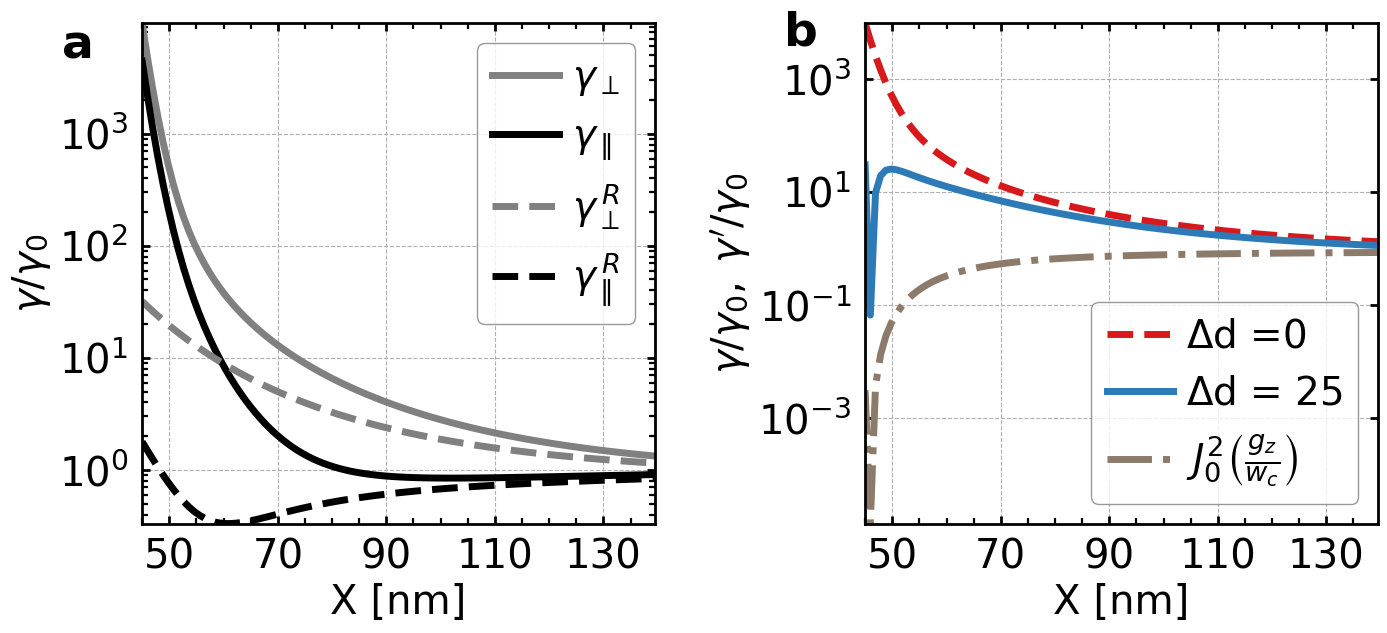

In [14]:
# Purcell effect, r = 45 nm
cm = 1/2.54 # used for figure size
fig, ax = plt.subplots(1,2, figsize = (40.5 * cm, 16.5 * cm))
plt.subplots_adjust(wspace=0.41)
col = ['gray', 'black', 'gray', 'black']

labels = ['$\gamma_{\perp}$', '$\gamma_{\, \|}$', '$\gamma^{\, R}_{\perp}$', '$\gamma^{\, R}_{\, \|}$']
lss = ['solid', 'solid', '--', '--']

# Plot decay rate enhancement
for o in range(4):
    ax[0].plot(x_arr44, plot_gammas4[o], label = labels[o], color = col[o], ls = lss[o], linewidth=5.0)

# Plot decay rates with and without Bessel correction for r = 10 nm
col = ['#d7191c', '#2c7bb6', '#8c7b6a']
lss = ['--', 'solid', '-.']
labels2 = ['$\Delta$d =$ 0$', f'$\Delta$d = {d_ii_4[5]}', r'$J_0^2 \left( \frac{g_z}{w_c} \right)$']

ax[1].plot(x_arr44, gamma_np4, label = labels2[0], color = col[0], ls = lss[0],linewidth=5.0)
ax[1].plot(x_arr44, gamma4, label = labels2[1], color = col[1], ls = lss[1],linewidth=5.0)
ax[1].plot(x_arr44, j_factor4, label = labels2[2], color = col[2], ls = lss[2],linewidth=5.0)

# formatting       
for i in range(2):
    ax[i].set_xlabel('X [nm]', fontsize=29)
    ax[i].set_ylabel('$\gamma / \gamma_0$', fontsize=29)
    ax[i].minorticks_on()
    ax[i].tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=29)
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(2.0)
    ax[i].grid(alpha = 1.0, ls = '--')
    ax[i].legend(fontsize=28,edgecolor='gray',handlelength=1.7, handletextpad=0.35)
    ax[i].tick_params(axis='x', width=2.0, length=6, direction='in', pad=10)
    ax[i].tick_params(axis='y', width=2.0, length=6, direction='in', pad=10)
    ax[i].tick_params(axis='x', which = 'minor', width=1.6, length=4, direction='in', pad=10)
    ax[i].tick_params(axis='y', which = 'minor', width=1.6, length=4, direction='in', pad=10)
    ax[i].set_yscale("log")
    ax[i].margins(x=0)
    ax[i].margins(y=0)
    ax[i].set_xticks([50,70,90,110,130])

ax[0].set_ylabel('$\gamma / \gamma_0$', fontsize=29)

ax[1].set_ylabel('$\gamma / \gamma_0, \; \gamma^{\prime} / \gamma_0$', fontsize=29)
ax[0].text(30.3,4.7e3,'a', fontsize = 34, weight='bold')
ax[1].text(30,4e3,'b', fontsize = 34, weight='bold')

offset_text_obj = ax[1].yaxis.get_offset_text()
offset_text_obj.set_fontsize(29)

# Save plot
plt.savefig(fname = f'decay_rates2.jpg', format = 'jpg', dpi=600, bbox_inches='tight')
plt.show()

### Evolution of the TLS

qutip_integration() calculates evolution of systems positioned at x_points (must be array even if single point) over the timeframe [0,tf] with either the transformed or full Hamiltonian equation

### r = 45 nm

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


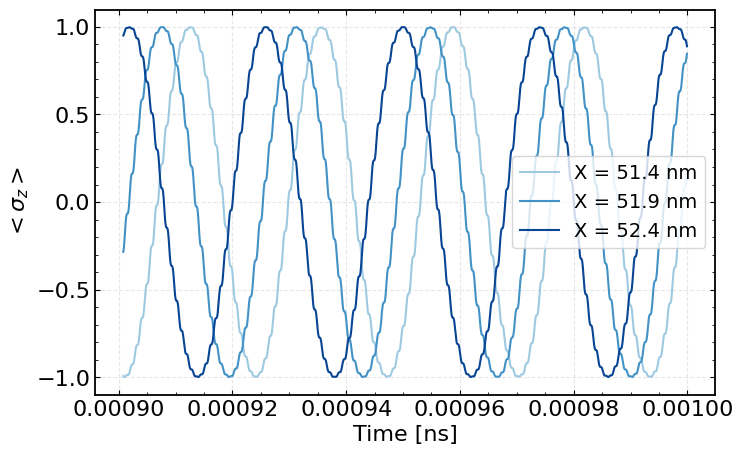

Omega 271915860904820.4 Delta 5108241468701.0 Gamma 3964869504.6360583 Gamma_prime 3964869504.6360583
Omega 266463763946670.06 Delta 4905241363492.5 Gamma 3314570616.77621 Gamma_prime 3314570616.77621
Omega 261210862229733.3 Delta 4713562597527.0 Gamma 2803123925.6692495 Gamma_prime 2803123925.6692495


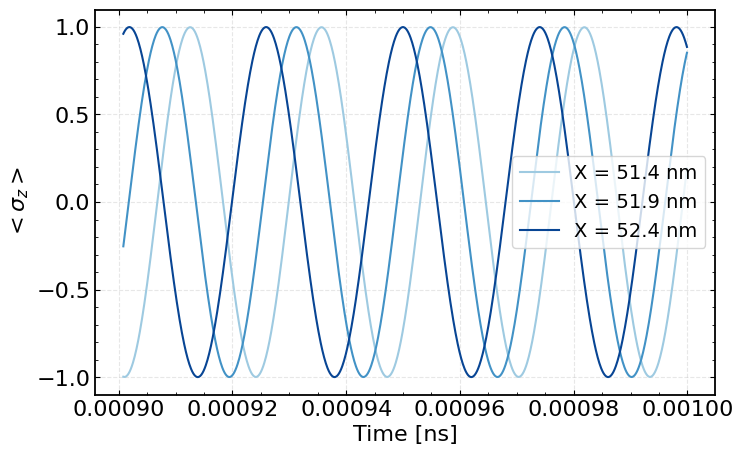

In [15]:
# Hamiltonian not transformed
times_no_dperm, results_no_dperm = qutip_integration(m_gold, ref_lam_gold, x_points = np.array([d_12[0]-0.5, d_12[0], d_12[0]+0.5]), 
                  d_perm = 0.0, E_0 = E_0_fixed, r = r4, lam_val = lam4, tf = 10.0002e-11, transformed_H = False,
                  k1 = 0.009008, k2 = 0.01, numtimes = 1000000)
# Hamiltonian transformed
times_no_dperm_tr, results_no_dperm_tr = qutip_integration(m_gold, ref_lam_gold, x_points = np.array([d_12[0]-0.5, d_12[0], d_12[0]+0.5]), 
                  d_perm = 0.0, E_0 = E_0_fixed, r = r4, lam_val = lam4, tf = 10.0002e-11, transformed_H = True,
                  k1 = 0.009008, k2 = 0.01, numtimes = 1000000)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


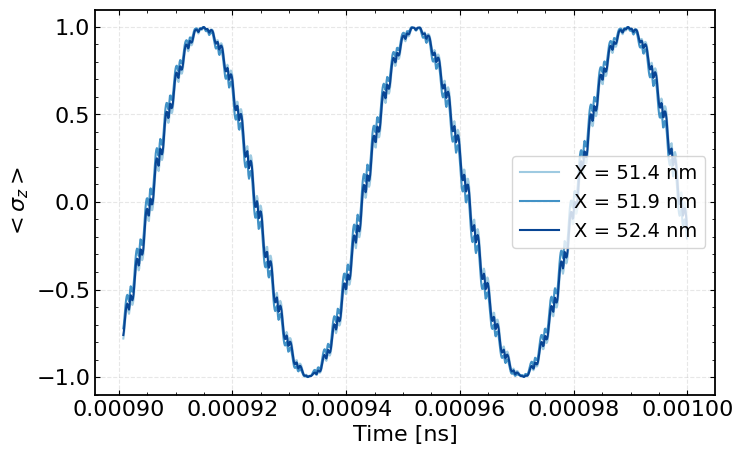

Omega 168519764978035.28 Delta 1960749350624.0 Gamma 345098254.6901081 Gamma_prime 345098254.6901081
Omega 168596985182942.56 Delta 1962547121117.5 Gamma 332946392.8210599 Gamma_prime 332946392.8210599
Omega 168511922870006.6 Delta 1960566186731.0 Gamma 320332982.8950467 Gamma_prime 320332982.8950467


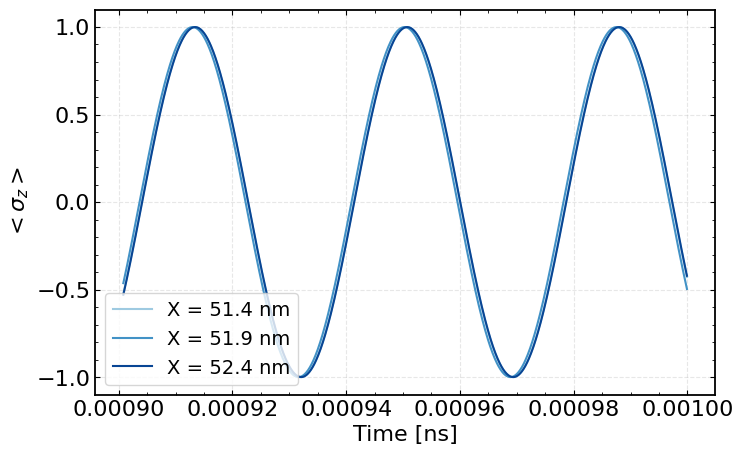

In [16]:
# Hamiltonian not transformed
times_dperm, results_dperm = qutip_integration(m_gold, ref_lam_gold, x_points = np.array([d_12[0]-0.5, d_12[0], d_12[0]+0.5]), 
                  d_perm = d_ii_4[5], E_0 = E_0_fixed, r = r4, lam_val = lam4, tf = 10.0002e-11, transformed_H = False,
                  k1 = 0.009008, k2 = 0.01, numtimes = 1000000)
# Hamiltonian transformed
times_dperm_tr, results_dperm_tr = qutip_integration(m_gold, ref_lam_gold, x_points = np.array([d_12[0]-0.5, d_12[0], d_12[0]+0.5]), 
                  d_perm = d_ii_4[5], E_0 = E_0_fixed, r = r4, lam_val = lam4, tf = 10.0002e-11, transformed_H = True,
                  k1 = 0.009008, k2 = 0.01, numtimes = 1000000)

In [17]:
start_time_early = 0.0 
start_time_late = 1.5e-2
end_time_ns_early = 3e-4
end_time_ns_late = start_time_late+3e-4

# convert to seconds
start_time_s_early = start_time_early * 1e-9
start_time_s_late = start_time_late * 1e-9
end_time_s_early = end_time_ns_early * 1e-9
end_time_s_late = end_time_ns_late * 1e-9

# find indices corresponding to start and end times
start_idx_no_dperm_tr_early = np.searchsorted(times_no_dperm_tr, start_time_s_early)
end_idx_no_dperm_tr_early = np.searchsorted(times_no_dperm_tr, end_time_s_early)
start_idx_dperm_tr_early = np.searchsorted(times_dperm_tr, start_time_s_early)
end_idx_dperm_tr_early = np.searchsorted(times_dperm_tr, end_time_s_early)

start_idx_no_dperm_tr_late = np.searchsorted(times_no_dperm_tr, start_time_s_late)
end_idx_no_dperm_tr_late = np.searchsorted(times_no_dperm_tr, end_time_s_late)
start_idx_dperm_tr_late = np.searchsorted(times_dperm_tr, start_time_s_late)
end_idx_dperm_tr_late = np.searchsorted(times_dperm_tr, end_time_s_late)

start_idx_no_dperm_early = np.searchsorted(times_no_dperm, start_time_s_early)
end_idx_no_dperm_early = np.searchsorted(times_no_dperm, end_time_s_early)
start_idx_dperm_early = np.searchsorted(times_dperm, start_time_s_early)
end_idx_dperm_early = np.searchsorted(times_dperm, end_time_s_early)

start_idx_no_dperm_late = np.searchsorted(times_no_dperm, start_time_s_late)
end_idx_no_dperm_late = np.searchsorted(times_no_dperm, end_time_s_late)
start_idx_dperm_late = np.searchsorted(times_dperm, start_time_s_late)
end_idx_dperm_late = np.searchsorted(times_dperm, end_time_s_late)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


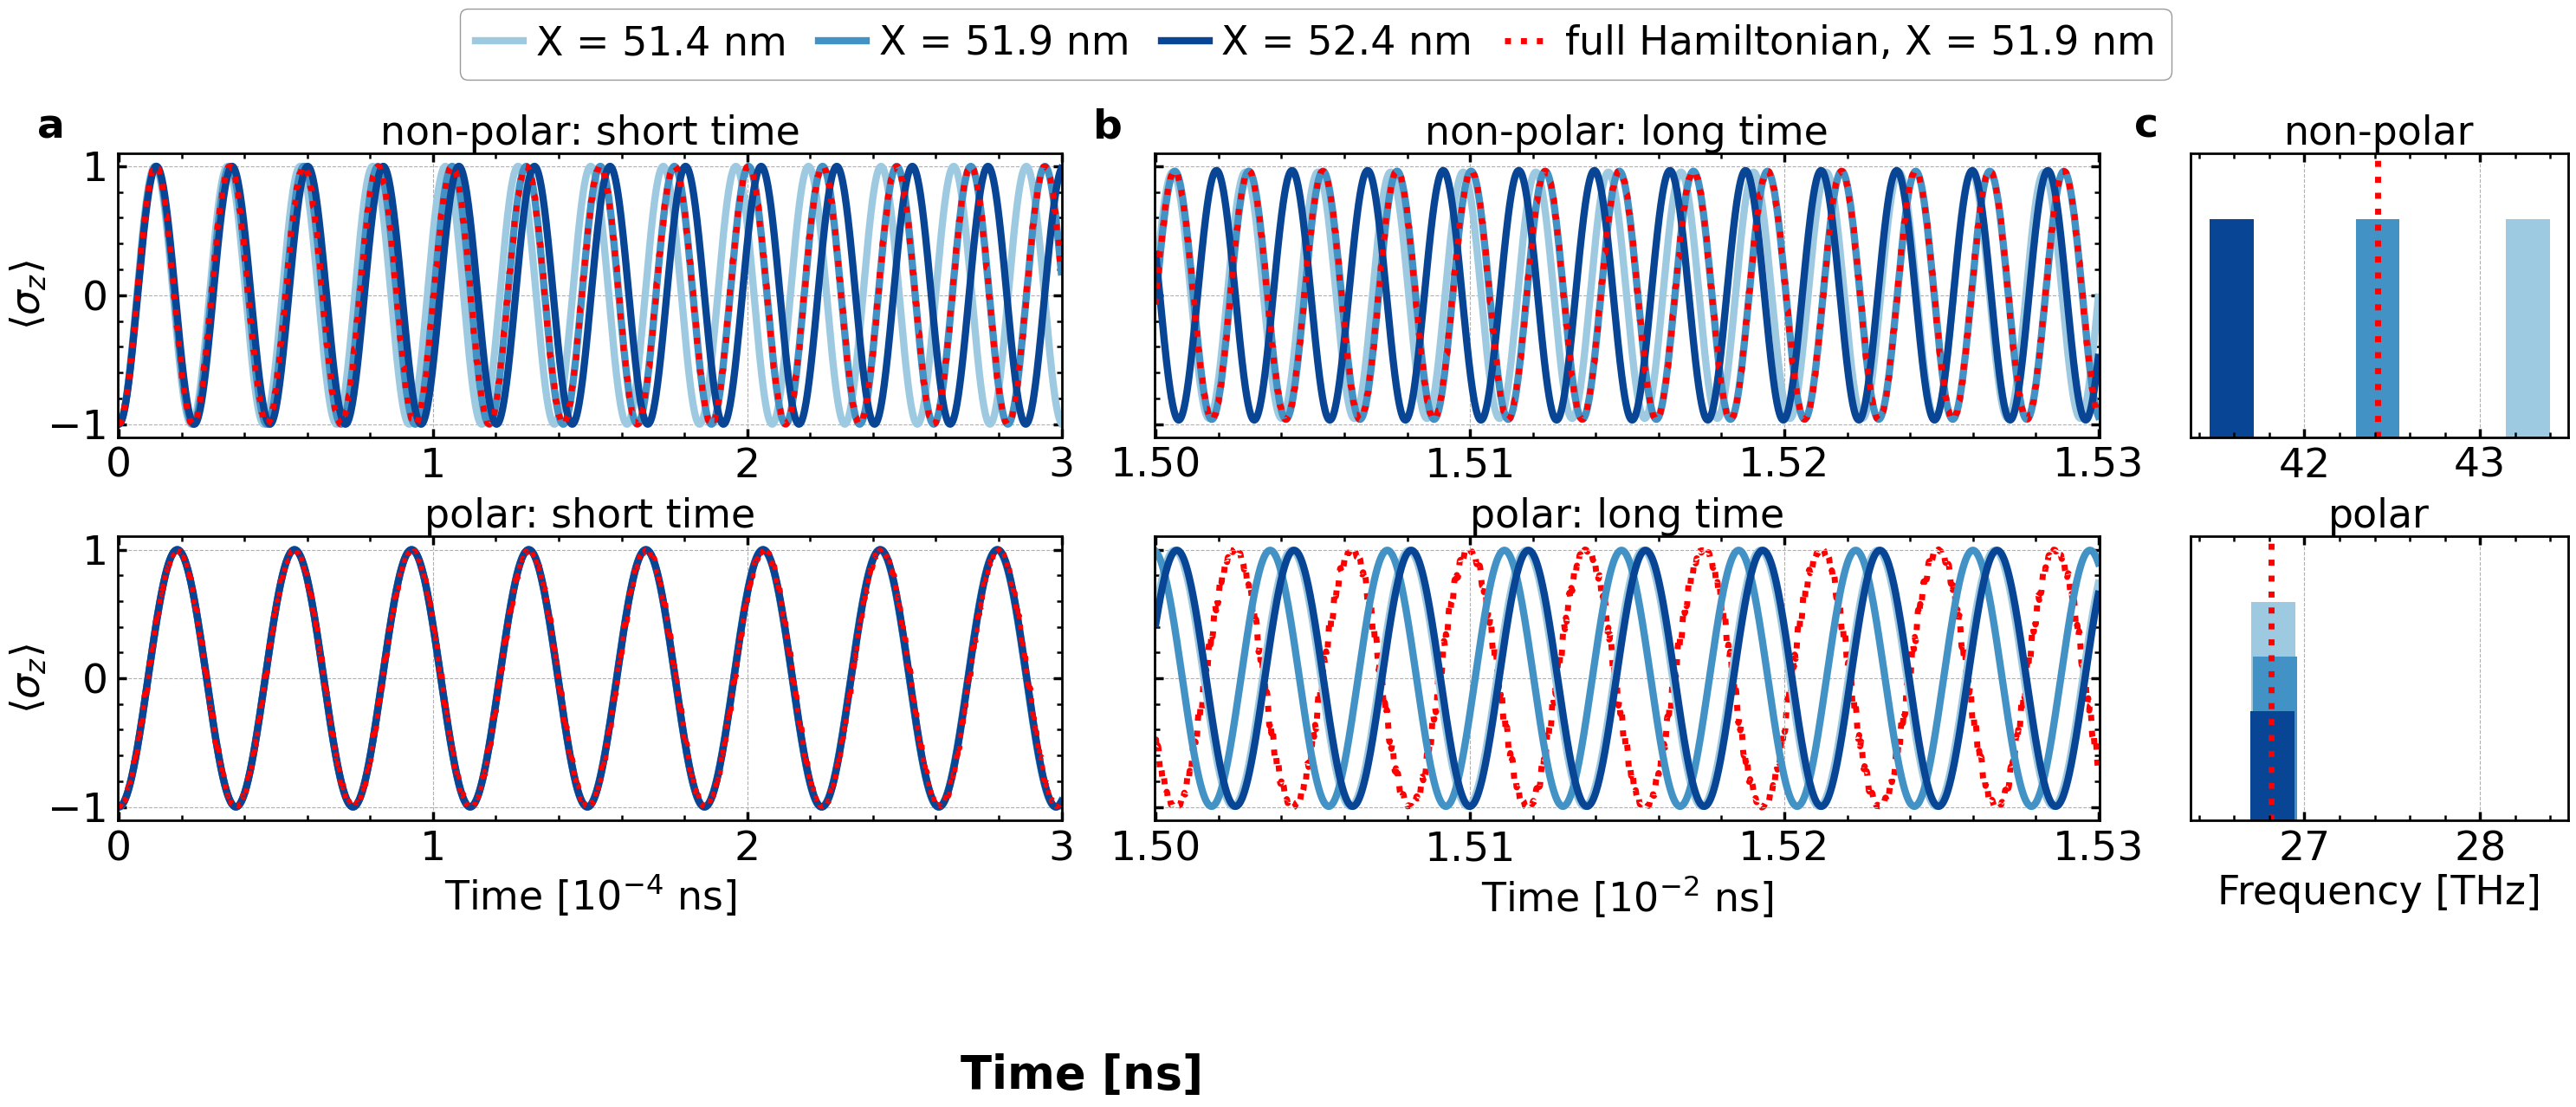

In [18]:
from scipy.signal import find_peaks

def estimate_fundamental_frequency(y, t, l=4, ymax=0.9):
    """find fundamental frequency of a sinusoidal signal"""

    # find peaks with minimum distance and prominence
    peaks, _ = find_peaks(y, distance=20, prominence=0.5, height=ymax)
    # check that the peaks are close to 1
    if not (np.isclose(y[peaks][0], 1, atol=0.1) and np.isclose(y[peaks][-1], 1, atol=0.1)):
        print("Warning: Peak values not close to 1")    
    # calculate periods and fundamental frequency
    peak_times = t[peaks]
    periods = np.diff(peak_times)
    fund_freq = 1 / np.mean(periods)
    
    return fund_freq

fig,ax = plt.subplots(2,5,figsize=(36.5,10.0), gridspec_kw={'width_ratios': [5, 0.01, 5, 0.001, 2]})
ax[0,2].sharey(ax[0,0])
ax[1,0].sharey(ax[1,2])
plt.subplots_adjust(hspace=0.35, wspace=0.1) 
fig.text(0.43, -0.2, 'Time [ns]', ha='center', fontsize=38, fontweight='bold')  # Adjust y (0.05) to place it nicely in white space
for spacer_col in [1, 3]:
    for row in range(2):
        ax[row, spacer_col].axis('off')
        
x_points1 = np.array([d_12[0]-0.5, d_12[0], d_12[0]+0.5])
col = ['#9ecae1','#4292c6','#084594']

# empty lists for storing fourier transform values
freq_no_dperm_tr_late = [] # transformed Hamiltonian, late times, no PDMs
freq_dperm_tr_late = [] # transformed Hamiltonian, late times, with PDMs
freq_no_dperm_late = [] # full Hamiltonian, late times, no PDMs
freq_dperm_late = [] # full Hamiltonian, late times, with PDMs

# plot solutions with transformed Hamiltonian
for i, res_no_dperm_tr in enumerate(results_no_dperm_tr): # without PDMs
    ax[0,0].plot(1e4*times_no_dperm_tr[start_idx_no_dperm_tr_early:end_idx_no_dperm_tr_early]*1e9, res_no_dperm_tr[start_idx_no_dperm_tr_early:end_idx_no_dperm_tr_early], 
               label = f'X = {x_points1[i]:.1f} nm', color = col[i], linewidth=6.0)
    ax[0,2].plot(1e2*times_no_dperm_tr[start_idx_no_dperm_tr_late:end_idx_no_dperm_tr_late]*1e9, res_no_dperm_tr[start_idx_no_dperm_tr_late:end_idx_no_dperm_tr_late], 
               label = f'X = {x_points1[i]:.1f} nm', color = col[i], linewidth=6.0)
    freq_no_dperm_tr_late.append(estimate_fundamental_frequency(res_no_dperm_tr[start_idx_no_dperm_tr_late:end_idx_no_dperm_tr_late], times_no_dperm_tr[start_idx_no_dperm_tr_late:end_idx_no_dperm_tr_late]))

for i, res_dperm_tr in enumerate(results_dperm_tr): # with PDMs
    ax[1,0].plot(1e4*times_dperm_tr[start_idx_dperm_tr_early:end_idx_dperm_tr_early]*1e9, res_dperm_tr[start_idx_dperm_tr_early:end_idx_dperm_tr_early], label = f'X = {x_points1[i]:.1f} nm',
               color = col[i], linewidth=6.0)
    ax[1,2].plot(1e2*times_dperm_tr[start_idx_dperm_tr_late:end_idx_dperm_tr_late]*1e9, res_dperm_tr[start_idx_dperm_tr_late:end_idx_dperm_tr_late], label = f'X = {x_points1[i]:.1f} nm',
               color = col[i], linewidth=6.0)
    freq_dperm_tr_late.append(estimate_fundamental_frequency(res_dperm_tr[start_idx_dperm_tr_late:end_idx_dperm_tr_late], times_dperm_tr[start_idx_dperm_tr_late:end_idx_dperm_tr_late]))
    
# plot solutions with full Hamiltonian
from itertools import islice
label = f'full Hamiltonian, X = {x_points1[1]:.1f} nm'
_, res_no_dperm = next(islice(enumerate(results_no_dperm, start=1), 1, None))
ax[0,0].plot(1e4*times_no_dperm[start_idx_no_dperm_early:end_idx_no_dperm_early]*1e9, res_no_dperm[start_idx_no_dperm_early:end_idx_no_dperm_early], 
    label = label, color = 'red', linestyle = ':', linewidth=5.0)
ax[0,2].plot(1e2*times_no_dperm[start_idx_no_dperm_late:end_idx_no_dperm_late]*1e9, res_no_dperm[start_idx_no_dperm_late:end_idx_no_dperm_late], 
    label = None, color = 'red', linestyle = ':', linewidth=5.0)

_, res_dperm = next(islice(enumerate(results_dperm, start=1), 1, None))
ax[1,0].plot(1e4*times_dperm[start_idx_dperm_early:end_idx_dperm_early]*1e9, res_dperm[start_idx_dperm_early:end_idx_dperm_early], 
    label = None, color = 'red', linestyle = ':', linewidth=4.0)
ax[1,2].plot(1e2*times_dperm[start_idx_dperm_late:end_idx_dperm_late]*1e9, res_dperm[start_idx_dperm_late:end_idx_dperm_late], 
    label = None, color = 'red', linestyle = ':', linewidth=5.0, zorder = 1)

# find frequencies associated with full Hamiltonian solutions
for i, res_no_dperm in enumerate(results_no_dperm):   
    freq_no_dperm_late.append(estimate_fundamental_frequency(res_no_dperm[start_idx_no_dperm_late:end_idx_no_dperm_late], times_no_dperm[start_idx_no_dperm_late:end_idx_no_dperm_late], ymax=0.0999999))
for i, res_dperm in enumerate(results_dperm):   
    freq_dperm_late.append(estimate_fundamental_frequency(res_dperm[start_idx_dperm_late:end_idx_dperm_late], times_dperm[start_idx_dperm_late:end_idx_dperm_late], ymax=1.0001))

# formatting the plot
ax[0,4].set_yticks([])      # remove y-axis ticks
ax[1,4].set_yticks([])      # remove y-axis ticks
for i in range(2):
    for j in range(2):
        ax[i,j].set_yticks([-1, 0, 1])
    for j in [0,2,4]:
        ax[i,j].minorticks_on()
        for axis in ['top','bottom','left','right']:
            ax[i,j].spines[axis].set_linewidth(2.0)
        ax[i,j].grid(alpha = 1.0, ls = '--')
        ax[i,j].xaxis.offsetText.set_visible(False)
        ax[i,j].tick_params(axis='both', right=True, top=True, width=2.5, length=7, direction='in', labelsize=34,pad=8)
        ax[i,j].tick_params(axis='both', right=True, top=True, which = 'minor', width=1.8, length=4, direction='in', labelsize=34, pad=0)
        ax[i,j].margins(x=0.001)
        ax[i,j].margins(y=0.05)
ax[0,2].tick_params(labelleft=False)
ax[1,2].tick_params(labelleft=False)
ax[0,0].set_xticks([0,1,2,3])
ax[1,0].set_xticks([0,1,2,3])
ax[0,2].set_xticks([1.50,1.51,1.52,1.53])
ax[1,2].set_xticks([1.50,1.51,1.52,1.53])

ax[1,2].set_xlabel('Time [$10^{-2}$ ns]', fontsize=33)
ax[1,0].set_xlabel('Time [$10^{-4}$ ns]', fontsize=33)
ax[0,0].set_ylabel(r'$\langle \sigma_z \rangle$', fontsize=33, labelpad=-1)
ax[1,0].set_ylabel(r'$\langle \sigma_z \rangle$', fontsize=33, labelpad=-1)

ax[0,0].set_title('non-polar: short time', fontsize=33)
ax[1,2].set_title('polar: long time', fontsize=33)
ax[0,2].set_title('non-polar: long time', fontsize=33)
ax[1,0].set_title('polar: short time', fontsize=33)

ax[1,4].set_xlabel('Frequency [THz]', fontsize=33)
ax[0,4].set_title('non-polar', fontsize=33)
ax[1,4].set_title('polar', fontsize=33)

# formatting the legend
data_handles, data_labels = ax[0,0].get_legend_handles_labels()
ncol = max(len(data_labels) // 2, 4)  # ensure at least 4 cols for better spacing
ax[0,2].legend(
    handles=data_handles,
    labels=data_labels,
    fontsize=33,
    loc='upper center',
    bbox_to_anchor=(0.17, 1.51),  # center above plot
    ncol=ncol,
    borderaxespad=0,
    columnspacing=0.8,
    handlelength=1.2,
    handletextpad=0.32,
    frameon=True,
    edgecolor='gray')  

# plot frequencies
for i in range(3):
    freq_dperm_late[i] *=1e-12 
    freq_dperm_tr_late[i] *= 1e-12
    freq_no_dperm_late[i] *= 1e-12
    freq_no_dperm_tr_late[i] *= 1e-12
ax[0,4].bar(freq_no_dperm_late, [0.8,0.8,0.8], color=col, width=0.25, zorder=0)
ax[1,4].bar(freq_dperm_tr_late, [0.8,0.6,0.4], color=col, width=0.25, zorder=0)

for i in range(1,2):
    ax[0,4].axvline(freq_no_dperm_late[i], color='red', linestyle = ':', linewidth=5.0, zorder=0)
    ax[1,4].axvline(freq_dperm_late[i], color='red', linestyle = ':', linewidth=5.0, zorder=0)

ax[0,4].set_xlim(82.7/2,87/2)      
ax[1,4].set_xlim(52.7/2,57/2)     
ax[0,4].set_ylim(0,1.04)     
ax[1,4].set_ylim(0,1.04)     
ax[1,4].set_xticks([27,28])      # remove y-axis ticks


ax[0,0].text(-0.26,1.22,'a', fontsize = 34, weight='bold')
ax[0,2].text(1.498,1.22,'b', fontsize = 34, weight='bold')
ax[0,4].text(41.03,1.1,'c', fontsize = 34, weight='bold')

plt.savefig(fname = f'evolution_r_vertical{r4*1e3}.jpg', format = 'jpg', dpi=600, bbox_inches='tight')
plt.show()    

### Electric field distribution over y = 0 cross section

Full field (incident + scattered)

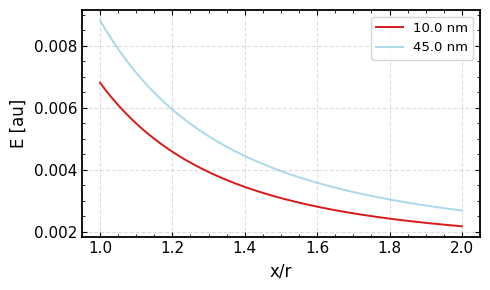

In [19]:
# plot field over y = 0 cross section
plot_E1 = []
plot_E4 = []
# r = 10 nm
for i in x_arr1:
    plot_E1.append(E_0_fixed*(scattered_field_absolute(i*1e-9, 0.0, 1e-15, m_gold, 
                                                     ref_lam_gold*1e-6, r1*1e-6, lam1*1e-6, 1)+1)) # in V/m
# r = 45 nm
for i in x_arr4:
    plot_E4.append(E_0_fixed*(scattered_field_absolute(i*1e-9, 0.0, 1e-15, m_gold, 
                                                     ref_lam_gold*1e-6, r4*1e-6, lam4*1e-6, 1)+1)) # in V/m
# Plot values (use x/r ratio so that both r1 and r4 values can be plotted on the same figure)
fig, ax = plt.subplots(1,1,figsize = (5,3), layout = 'tight')
ax.plot(x_arr1/(r1*1e3), plot_E1, color = '#d7191c', ls = 'solid', label = f'{r1*1e3} nm', linewidth = 1.4)
ax.plot(x_arr4/(r4*1e3), plot_E4, color = '#abd9e9', ls = 'solid', label = f'{r4*1e3} nm', linewidth = 1.4, 
        zorder = 0)
# Plotting style
ax.set_xlabel('x/r', fontsize=12)
ax.set_ylabel('E [au]', fontsize=12)
ax.minorticks_on()
ax.tick_params(axis="both", direction="in", which="both", right=True, top=True, labelsize=11)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.3)
ax.grid(alpha = 0.4, ls = '--')
ax.legend(fontsize=9.5)
# Save plot    
plt.savefig(fname = f'field_cross_section_r_{r4*1e3:.0f}.jpg', format = 'jpg', dpi=800)
plt.show()